# Interpreting the Models

Notebook 5 completed the final performance evaluation without changing the models or their thresholds. Gradient boosting remains the primary model and its 0.130 operating threshold remains frozen.

This notebook asks a different question: **what information are the models using to make those predictions?**

The analysis moves from the most transparent model to the most flexible one. Each step answers a narrower question than the one before it:

1. **Read the logistic-regression coefficients and odds ratios.**
   Logistic regression assigns every predictor a single number describing which way it pushes the fitted risk. This is the clearest statement of direction the project can make, so it comes first. Odds ratios put those coefficients on a readable multiplicative scale.

2. **Compare random-forest and gradient-boosting split importance.**
   Tree models record how often each feature was chosen for a split and how much those splits improved the fit. Reporting both models together shows whether they rely on the same predictors. Agreement suggests a stable signal; disagreement suggests the ranking is fragile. Split importance also favors features with many distinct values, such as age, over binary indicators, which is one reason it is not the only measure used here.

3. **Calculate both individual-column and grouped permutation importance.**
   Permutation importance shuffles a feature and measures how much predictive performance falls, so it scores every model on the same scale and in terms of the metric that matters. Grouped permutation shuffles related columns together, because race is spread across five indicators and income across a value and a missingness flag. Shuffling those one at a time understates them, since the remaining columns still carry the information.

4. **Use SHAP to show the size and direction of gradient boosting's contributions.**
   Importance rankings say how much a feature matters overall but not which way it points. SHAP decomposes each individual prediction into per-feature contributions that sum to that prediction, so the analysis can report both an overall ranking and the direction of each predictor's effect across the cohort.

5. **Explain representative correct and incorrect predictions.**
   Aggregate summaries hide how the model behaves for real participants. Walking through a true positive, a true negative, a false positive, and a false negative shows what drove each decision. False negatives matter most: the 0.130 threshold was chosen to protect recall, so a missed cavity points to a genuine gap in the feature set.

6. **Run the three preplanned sensitivity analyses.**
   These comparisons were specified before any results were seen, so they test the model rather than search for a favorable framing. Each one is refit on the training data with cross-validation; the test set already produced the final numbers in Notebook 5 and is not reused to compare variants.
   - **Remove self-rated teeth condition** to measure how much of the performance depends on a predictor that sits close to the outcome. The questionnaire was completed during the household interview, separately from the dental examination at the mobile examination center, so the rating is not taken from the examination itself. It may still reflect symptoms of caries the participant already has, which makes it a contemporaneous screening signal rather than a prediction of future disease.
   - **Remove race/ethnicity** to see whether the model still performs comparably without demographic indicators that stand in for access, exposures, and social conditions rather than biology.
   - **Compare the full imputed cohort with complete-income participants** to check whether imputing missing income changed the conclusions, or whether the missingness itself carries information.

Nothing here changes the primary model, its hyperparameters, or its threshold. This is post-hoc interpretation of an already finalized model.

## What Interpretation Can and Cannot Tell Us

A feature can be important because it contains useful predictive information. That does **not** prove that changing the feature would change a person's cavity status.

- **Prediction is not causation.** These are observational NHANES data.
- **Importance depends on this feature set.** Correlated predictors can share or hide each other's importance.
- **Demographic variables require care.** Race and ethnicity may reflect differences in access, exposures, and social conditions. Their contributions should not be interpreted as biological effects.

The goal is to understand the fitted models honestly, not to turn their internal patterns into clinical claims.

## Intended Use and Survey Design

The intended use is **questionnaire-based screening and referral prioritization before a dental examination**. The model is not a diagnostic system and does not replace an examination by a dental professional.

That use case matters for self-rated teeth condition. A screening questionnaire can legitimately ask participants how their teeth feel or look before an examination. In NHANES the questionnaire is completed during the household interview, separately from the dental examination at the mobile examination center, so the self-rating is not a restatement of the examiner's findings. It can still reflect symptoms of caries that are already present, so it is best understood as a contemporaneous screening signal rather than a prediction of future disease: the model is partly formalizing what participants already recognize about their own oral health.

NHANES survey weights are deliberately excluded because this project predicts outcomes for individual participants rather than estimating national prevalence. Therefore, every importance value and sensitivity result describes this unweighted analytic cohort. The random training/test split also does not account for NHANES sampling strata or primary-sampling-unit clustering, which limits population-level interpretation.

## Imports and Setup

In [1]:
from pathlib import Path
import hashlib
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

try:
    import shap
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "SHAP is missing. Run `pip install -r requirements.txt`, "
        "restart the kernel, and rerun this notebook."
    ) from error

try:
    from IPython.display import Markdown, display
except ImportError:
    # Jupyter supplies these automatically. The fallback keeps the
    # notebook readable if a cell is executed as ordinary Python.
    def display(value):
        print(value)

    def Markdown(value):
        return value

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline


# Find the project folder whether Jupyter starts from the repository
# root or from inside the notebooks folder.
current_folder = Path.cwd().resolve()
for candidate in [current_folder, current_folder.parent]:
    if (candidate / "data" / "processed" / "test_data.csv").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Could not find data/processed/test_data.csv. Open this "
        "notebook from inside the project repository."
    )

TRAINING_PATH = PROJECT_ROOT / "data" / "processed" / "training_data.csv"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "test_data.csv"
MODEL_FOLDER = PROJECT_ROOT / "outputs" / "models"
TABLE_FOLDER = PROJECT_ROOT / "outputs" / "tables"

TRAINING_METADATA_PATH = MODEL_FOLDER / "model_metadata.json"
EVALUATION_METADATA_PATH = MODEL_FOLDER / "test_evaluation_metadata.json"
TEST_RESULTS_PATH = TABLE_FOLDER / "model_test_results.csv"
TEST_PREDICTIONS_PATH = TABLE_FOLDER / "model_test_predictions.csv"
DEVELOPMENT_RESULTS_PATH = (
    TABLE_FOLDER / "model_development_cv_results.csv"
)

RANDOM_STATE = 42
N_PERMUTATION_REPEATS = 30

PURPLE = "#5d32ca"
GREEN = "#82b600"
ORANGE = "#f59e0b"
BLUE = "#2f80ed"
GRAY = "#8a8a8a"

MODEL_COLORS = {
    "Logistic Regression": PURPLE,
    "Random Forest": GREEN,
    "Gradient Boosting": ORANGE,
    "Neural Network": BLUE,
}

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

print(f"Project folder: {PROJECT_ROOT.name}")
print(f"SHAP version: {shap.__version__}")

Project folder: Dental Caries Prediction Project
SHAP version: 0.52.0


## Loading and Verifying the Finalized Project

This notebook loads the complete pipelines saved by Notebook 4 and verifies them against Notebook 5's metadata. SHA-256 checks stop the notebook if a data or model file has changed since final evaluation.

In [2]:
required_artifacts = [
    TRAINING_PATH,
    TEST_PATH,
    TRAINING_METADATA_PATH,
    EVALUATION_METADATA_PATH,
    TEST_RESULTS_PATH,
    TEST_PREDICTIONS_PATH,
    DEVELOPMENT_RESULTS_PATH,
]

missing_artifacts = [path for path in required_artifacts if not path.exists()]
if missing_artifacts:
    missing_text = "\n".join(f"- {path}" for path in missing_artifacts)
    raise FileNotFoundError(
        "Run the final versions of Notebooks 4 and 5 first. "
        f"These artifacts are missing:\n{missing_text}"
    )

training_metadata = json.loads(TRAINING_METADATA_PATH.read_text())
evaluation_metadata = json.loads(EVALUATION_METADATA_PATH.read_text())

feature_columns = training_metadata["features"]
target_column = training_metadata["target"]
primary_model = evaluation_metadata["primary_model"]
frozen_thresholds = evaluation_metadata["frozen_thresholds"]
primary_threshold = frozen_thresholds[primary_model]

model_filenames = {
    "Logistic Regression": "logistic_regression.joblib",
    "Random Forest": "random_forest.joblib",
    "Gradient Boosting": "gradient_boosting.joblib",
    "Neural Network": "neural_network.joblib",
}

# These hashes connect the exact data and model files used in Notebooks
# 4 and 5 to the explanations produced here.
current_training_hash = hashlib.sha256(TRAINING_PATH.read_bytes()).hexdigest()
current_test_hash = hashlib.sha256(TEST_PATH.read_bytes()).hexdigest()

assert current_training_hash == training_metadata["training_file_sha256"]
assert current_training_hash == evaluation_metadata[
    "source_training_file_sha256"
]
assert current_test_hash == evaluation_metadata["test_file_sha256"]
assert primary_model == "Gradient Boosting"

fitted_models = {}
verification_rows = []

for model_name, filename in model_filenames.items():
    model_path = MODEL_FOLDER / filename
    if not model_path.exists():
        raise FileNotFoundError(
            f"{filename} is missing. Rerun Notebook 4."
        )

    current_hash = hashlib.sha256(model_path.read_bytes()).hexdigest()
    expected_hash = evaluation_metadata["model_sha256"][model_name]
    if current_hash != expected_hash:
        raise RuntimeError(
            f"{model_name} does not match the model evaluated in "
            "Notebook 5. Rerun Notebooks 4 and 5 in order."
        )

    fitted_models[model_name] = joblib.load(model_path)
    verification_rows.append(
        {
            "Model": model_name,
            "Pipeline": " → ".join(fitted_models[model_name].named_steps),
            "Matches Notebook 5": True,
        }
    )

print(f"Primary model: {primary_model}")
print(f"Frozen threshold: {primary_threshold:.3f}")
pd.DataFrame(verification_rows)

Primary model: Gradient Boosting
Frozen threshold: 0.130


,Model,Pipeline,Matches Notebook 5
0,Logistic Regression,preprocessor → model,True
1,Random Forest,preprocessor → model,True
2,Gradient Boosting,preprocessor → model,True
3,Neural Network,preprocessor → model,True


## Loading the Interpretation Data

`training_data.csv` is used only for the preplanned sensitivity analysis. `test_data.csv` is used for post-hoc permutation importance and SHAP explanations. Test outcomes never select a new model, setting, or threshold.

In [3]:
training_data = pd.read_csv(TRAINING_PATH)
test_data = pd.read_csv(TEST_PATH)
saved_test_predictions = pd.read_csv(TEST_PREDICTIONS_PATH)
test_results = pd.read_csv(TEST_RESULTS_PATH)
development_results = pd.read_csv(DEVELOPMENT_RESULTS_PATH)

required_columns = {"SEQN", target_column, *feature_columns}
assert required_columns.issubset(training_data.columns)
assert required_columns.issubset(test_data.columns)
assert training_data["SEQN"].is_unique
assert test_data["SEQN"].is_unique
assert set(training_data["SEQN"]).isdisjoint(test_data["SEQN"])

X_train = training_data[feature_columns].copy()
y_train = training_data[target_column].astype(int)
X_test = test_data[feature_columns].copy()
y_test = test_data[target_column].astype(int)

primary_pipeline = fitted_models[primary_model]
primary_probabilities = primary_pipeline.predict_proba(X_test)[:, 1]
primary_predictions = (primary_probabilities >= primary_threshold).astype(int)

# These must match the exact probabilities and flags already saved by
# Notebook 5. Notebook 6 is not allowed to create a new evaluation.
assert saved_test_predictions["SEQN"].equals(test_data["SEQN"])
assert np.allclose(
    primary_probabilities,
    saved_test_predictions["gradient_boosting_probability"],
)
assert np.array_equal(
    primary_predictions,
    saved_test_predictions["gradient_boosting_prediction"],
)

data_summary = pd.DataFrame(
    {
        "Dataset": ["Training", "Test"],
        "Participants": [len(training_data), len(test_data)],
        "Cavity cases": [int(y_train.sum()), int(y_test.sum())],
        "Cavity prevalence": [
            f"{y_train.mean():.1%}",
            f"{y_test.mean():.1%}",
        ],
        "Used here for": [
            "Training-only sensitivity analyses",
            "Final-model importance and explanations",
        ],
    }
)
display(data_summary)

# Report the already-finalized Notebook 5 result from its saved table,
# rather than typing values into markdown that could later drift.
primary_test_row = test_results.loc[
    test_results["Model"] == primary_model
].iloc[0]

display(
    Markdown(
        f"Notebook 5's frozen **{primary_model}** result was "
        f"**{primary_test_row['PR-AUC']:.3f} PR-AUC** and "
        f"**{primary_test_row['Recall']:.3f} recall** at the "
        f"precommitted **{primary_threshold:.3f} threshold**. "
        "Those numbers are context only; they are not recalculated or "
        "optimized here."
    )
)

,Dataset,Participants,Cavity cases,Cavity prevalence,Used here for
0,Training,10572,1936,18.3%,Training-only sensitivity analyses
1,Test,2643,484,18.3%,Final-model importance and explanations


Notebook 5's frozen **Gradient Boosting** result was **0.449 PR-AUC** and **0.818 recall** at the precommitted **0.130 threshold**. Those numbers are context only; they are not recalculated or optimized here.

## Reading the Predictors Correctly

Higher dental-visit recency number means a **less recent** visit. Higher self-rated teeth condition means **worse** condition. All race indicators equal to zero represents the non-Hispanic White reference group.

In [4]:
feature_labels = {
    "age": "Age",
    "income_poverty_ratio": "Income-to-poverty ratio",
    "dental_visit_recency_ord": "Dental-visit recency",
    "teeth_condition_ord": "Self-rated teeth condition",
    "sex_female": "Female sex",
    "diabetes_yes": "Diagnosed diabetes",
    "diabetes_borderline": "Borderline diabetes",
    "race_mexican_american": "Mexican American",
    "race_other_hispanic": "Other Hispanic",
    "race_non-hispanic_black": "Non-Hispanic Black",
    "race_non-hispanic_asian": "Non-Hispanic Asian",
    "race_other_multi": "Other or multiracial",
    "income_poverty_ratio_missing": "Income missing",
}

feature_meanings = {
    "age": "Age in years",
    "income_poverty_ratio": "Family income divided by the federal poverty threshold",
    "dental_visit_recency_ord": "1 = ≤6 months through 7 = never",
    "teeth_condition_ord": "1 = excellent through 5 = poor",
    "sex_female": "1 = female; reference is male",
    "diabetes_yes": "1 = diagnosed diabetes; reference is no diabetes",
    "diabetes_borderline": "1 = borderline diabetes; reference is no diabetes",
    "race_mexican_american": "1 = Mexican American",
    "race_other_hispanic": "1 = other Hispanic",
    "race_non-hispanic_black": "1 = non-Hispanic Black",
    "race_non-hispanic_asian": "1 = non-Hispanic Asian",
    "race_other_multi": "1 = other or multiracial",
    "income_poverty_ratio_missing": "1 = income was missing and imputed",
}

feature_guide = pd.DataFrame(
    {
        "Model column": feature_columns,
        "Readable feature": [feature_labels[x] for x in feature_columns],
        "Meaning": [feature_meanings[x] for x in feature_columns],
    }
)

race_mask = feature_guide["Model column"].str.startswith("race_")
feature_guide.loc[race_mask, "Meaning"] += (
    "; reference is non-Hispanic White"
)
feature_guide

,Model column,Readable feature,Meaning
0,age,Age,Age in years
1,income_poverty_ratio,Income-to-poverty ratio,Family income divided by the federal poverty threshold
2,dental_visit_recency_ord,Dental-visit recency,1 = ≤6 months through 7 = never
3,teeth_condition_ord,Self-rated teeth condition,1 = excellent through 5 = poor
4,sex_female,Female sex,1 = female; reference is male
5,diabetes_yes,Diagnosed diabetes,1 = diagnosed diabetes; reference is no diabetes
6,diabetes_borderline,Borderline diabetes,1 = borderline diabetes; reference is no diabetes
7,race_mexican_american,Mexican American,1 = Mexican American; reference is non-Hispanic White
8,race_other_hispanic,Other Hispanic,1 = other Hispanic; reference is non-Hispanic White
9,race_non-hispanic_black,Non-Hispanic Black,1 = non-Hispanic Black; reference is non-Hispanic White


## Logistic Regression: Direction and Size

A positive coefficient raises the fitted log-odds of a cavity; a negative coefficient lowers them, holding the other predictors fixed.

The four continuous or ordered predictors were standardized. Their odds ratios represent a **one-training-standard-deviation increase**. Binary indicators remain on their original 0/1 scale.

These are regularized predictive coefficients—not causal effects, p-values, or classical confidence intervals.

In [5]:
logistic_pipeline = fitted_models["Logistic Regression"]
logistic_preprocessor = logistic_pipeline.named_steps["preprocessor"]
logistic_estimator = logistic_pipeline.named_steps["model"]

assert logistic_preprocessor.get_feature_names_out().tolist() == feature_columns

# Define the expected order explicitly. Pairing scaler values with
# feature_columns[:4] would silently become wrong if a future notebook
# reordered its predictors.
scaled_features = [
    "age",
    "income_poverty_ratio",
    "dental_visit_recency_ord",
    "teeth_condition_ord",
]
fitted_scaled_columns = list(
    logistic_preprocessor.transformers_[0][2]
)
assert fitted_scaled_columns == scaled_features

scaled_pipeline = logistic_preprocessor.named_transformers_["scaled"]
training_scales = scaled_pipeline.named_steps["scaler"].scale_
assert len(training_scales) == len(scaled_features)
scale_lookup = dict(zip(scaled_features, training_scales))

binary_comparisons = {
    "sex_female": "female compared with male",
    "diabetes_yes": "diagnosed diabetes compared with no diabetes",
    "diabetes_borderline": "borderline diabetes compared with no diabetes",
    "race_mexican_american": "Mexican American vs non-Hispanic White",
    "race_other_hispanic": "other Hispanic vs non-Hispanic White",
    "race_non-hispanic_black": "non-Hispanic Black vs non-Hispanic White",
    "race_non-hispanic_asian": "non-Hispanic Asian vs non-Hispanic White",
    "race_other_multi": "other/multiracial vs non-Hispanic White",
    "income_poverty_ratio_missing": "income missing vs reported",
}

changes = []
units = {
    "age": "years",
    "income_poverty_ratio": "ratio units",
    "dental_visit_recency_ord": "ordered levels",
    "teeth_condition_ord": "ordered levels",
}

for feature in feature_columns:
    if feature in scale_lookup:
        changes.append(
            f"{scale_lookup[feature]:.2f} {units[feature]} "
            "(1 training SD)"
        )
    else:
        changes.append(binary_comparisons[feature])

logistic_coefficients = pd.DataFrame(
    {
        "Feature": feature_columns,
        "Readable feature": [feature_labels[x] for x in feature_columns],
        "Change represented": changes,
        "Coefficient": logistic_estimator.coef_[0],
    }
)
logistic_coefficients["Odds ratio"] = np.exp(
    logistic_coefficients["Coefficient"]
)
logistic_coefficients["Absolute coefficient"] = (
    logistic_coefficients["Coefficient"].abs()
)
logistic_coefficients["Direction"] = np.where(
    logistic_coefficients["Coefficient"] >= 0,
    "Higher predicted odds",
    "Lower predicted odds",
)
logistic_coefficients = logistic_coefficients.sort_values(
    "Coefficient", ascending=False
).reset_index(drop=True)

logistic_coefficients[
    [
        "Readable feature",
        "Change represented",
        "Coefficient",
        "Odds ratio",
        "Direction",
    ]
].round(3)

,Readable feature,Change represented,Coefficient,Odds ratio,Direction
0,Self-rated teeth condition,1.18 ordered levels (1 training SD),0.770,2.159,Higher predicted odds
1,Non-Hispanic Black,non-Hispanic Black vs non-Hispanic White,0.258,1.294,Higher predicted odds
2,Dental-visit recency,1.98 ordered levels (1 training SD),0.217,1.242,Higher predicted odds
3,Other or multiracial,other/multiracial vs non-Hispanic White,0.213,1.238,Higher predicted odds
4,Income missing,income missing vs reported,0.152,1.165,Higher predicted odds
5,Diagnosed diabetes,diagnosed diabetes compared with no diabetes,-0.064,0.938,Lower predicted odds
6,Other Hispanic,other Hispanic vs non-Hispanic White,-0.076,0.927,Lower predicted odds
7,Female sex,female compared with male,-0.118,0.889,Lower predicted odds
8,Non-Hispanic Asian,non-Hispanic Asian vs non-Hispanic White,-0.132,0.876,Lower predicted odds
9,Age,24.75 years (1 training SD),-0.137,0.872,Lower predicted odds


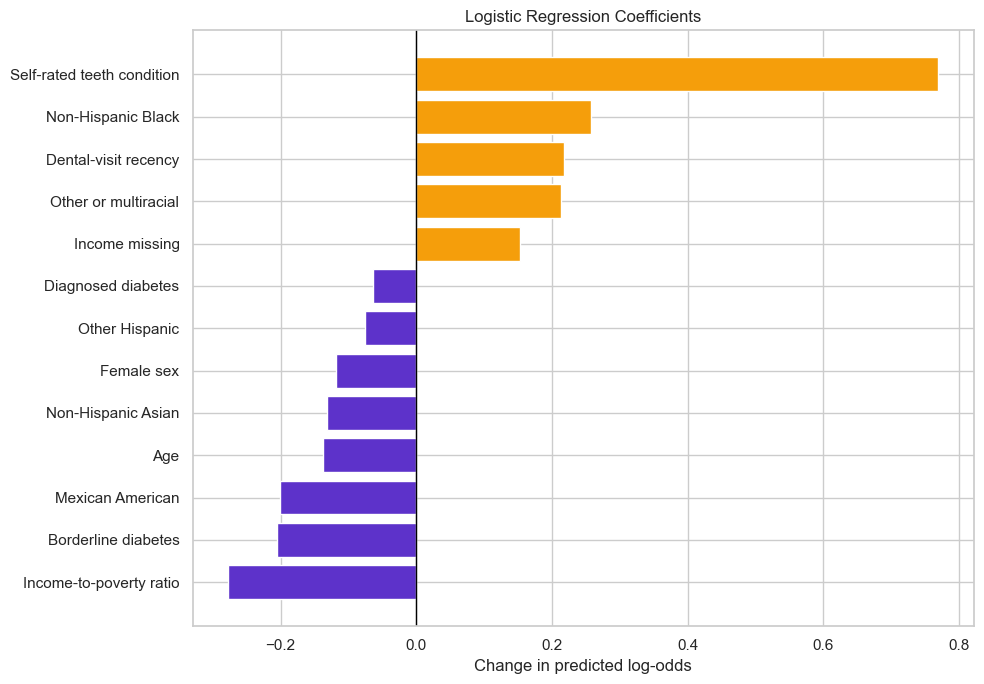

In [6]:
coefficient_plot = logistic_coefficients.sort_values("Coefficient")
colors = np.where(coefficient_plot["Coefficient"] >= 0, ORANGE, PURPLE)

plt.figure(figsize=(10, 7))
plt.barh(
    coefficient_plot["Readable feature"],
    coefficient_plot["Coefficient"],
    color=colors,
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Change in predicted log-odds")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [7]:
# Explaining from the executed coefficient table so the
# written result cannot disagree with the values above.
largest_logistic = logistic_coefficients.nlargest(
    1, "Absolute coefficient"
).iloc[0]
income_logistic = logistic_coefficients.loc[
    logistic_coefficients["Feature"] == "income_poverty_ratio"
].iloc[0]

display(
    Markdown(
        f"**{largest_logistic['Readable feature']}** has the largest "
        f"absolute logistic coefficient "
        f"({largest_logistic['Coefficient']:.3f}; odds ratio "
        f"{largest_logistic['Odds ratio']:.3f} for the change shown in "
        "the table). The income-to-poverty coefficient is "
        f"{income_logistic['Coefficient']:.3f}, corresponding to an "
        f"odds ratio of {income_logistic['Odds ratio']:.3f}. "
        "These are conditional predictive associations, not causal "
        "effects."
    )
)

**Self-rated teeth condition** has the largest absolute logistic coefficient (0.770; odds ratio 2.159 for the change shown in the table). The income-to-poverty coefficient is -0.277, corresponding to an odds ratio of 0.758. These are conditional predictive associations, not causal effects.

## Tree-Based Split Importance

Random forest and gradient boosting do not have one coefficient per predictor. Their built-in importance totals how much each feature improved tree splits. A value of 0.20 means about 20% of the model's total split improvement, not 20% of cavities explained.

In [8]:
tree_rows = []

for model_name in ["Random Forest", "Gradient Boosting"]:
    pipeline = fitted_models[model_name]
    names = pipeline.named_steps["preprocessor"].get_feature_names_out().tolist()
    assert names == feature_columns

    for feature, importance in zip(
        names,
        pipeline.named_steps["model"].feature_importances_,
    ):
        tree_rows.append(
            {
                "Model": model_name,
                "Feature": feature,
                "Readable feature": feature_labels[feature],
                "Split importance": importance,
            }
        )

tree_importances = pd.DataFrame(tree_rows)
tree_importance_wide = (
    tree_importances.pivot(
        index=["Feature", "Readable feature"],
        columns="Model",
        values="Split importance",
    )
    .reset_index()
    .sort_values("Gradient Boosting", ascending=False)
)

tree_importance_wide[
    ["Readable feature", "Random Forest", "Gradient Boosting"]
].round(3)

Model,Readable feature,Random Forest,Gradient Boosting
12,Self-rated teeth condition,0.248,0.476
0,Age,0.257,0.155
1,Dental-visit recency,0.127,0.152
4,Income-to-poverty ratio,0.237,0.134
8,Non-Hispanic Black,0.027,0.029
10,Other or multiracial,0.011,0.011
6,Mexican American,0.016,0.010
11,Female sex,0.028,0.008
3,Diagnosed diabetes,0.012,0.007
5,Income missing,0.014,0.005


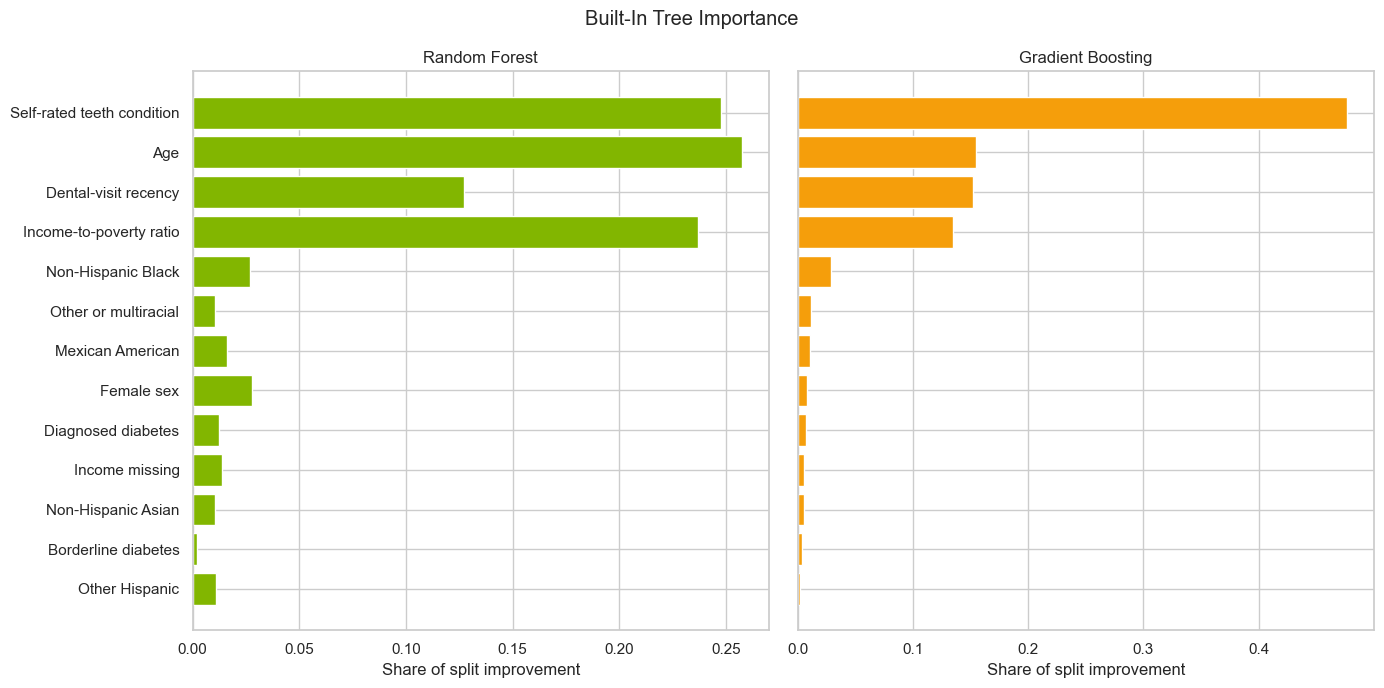

In [9]:
figure, axes = plt.subplots(1, 2, figsize=(14, 7), sharey=True)
feature_order = tree_importance_wide["Readable feature"].tolist()[::-1]

for axis, model_name in zip(
    axes, ["Random Forest", "Gradient Boosting"]
):
    model_data = tree_importances.loc[
        tree_importances["Model"] == model_name
    ].set_index("Readable feature").loc[feature_order].reset_index()

    axis.barh(
        model_data["Readable feature"],
        model_data["Split importance"],
        color=MODEL_COLORS[model_name],
    )
    axis.set_title(model_name)
    axis.set_xlabel("Share of split improvement")
    axis.set_ylabel("")

figure.suptitle("Built-In Tree Importance")
plt.tight_layout()
plt.show()

In [10]:
rf_top = tree_importance_wide.nlargest(4, "Random Forest")
gb_top = tree_importance_wide.nlargest(4, "Gradient Boosting")

display(
    Markdown(
        "The four largest built-in importances are "
        f"**{', '.join(gb_top['Readable feature'])}** for gradient "
        "boosting and "
        f"**{', '.join(rf_top['Readable feature'])}** for random "
        "forest. Split importance is useful, but it can favor variables "
        "with more possible cut points. The permutation analysis below "
        "checks model dependence using a different method."
    )
)

The four largest built-in importances are **Self-rated teeth condition, Age, Dental-visit recency, Income-to-poverty ratio** for gradient boosting and **Age, Self-rated teeth condition, Income-to-poverty ratio, Dental-visit recency** for random forest. Split importance is useful, but it can favor variables with more possible cut points. The permutation analysis below checks model dependence using a different method.

## Individual and Grouped Permutation Importance

Standard permutation importance shuffles one column at a time. That is appropriate for age or self-rated teeth condition, but it can create impossible combinations when applied separately to one-hot encoded variables:

- two race indicators may become 1 at the same time;
- diagnosed and borderline diabetes may both become 1;
- the income value may no longer agree with its missingness indicator.

This notebook therefore reports two versions:

1. **Per-column importance** for direct comparison with SHAP and split importance.
2. **Grouped importance** as the preferred result for race/ethnicity, diabetes status, and income. Every encoded block is moved together, preserving valid combinations.

In both versions, importance is the decrease in finalized test PR-AUC after shuffling. The 30-repeat spread measures permutation randomness, not population uncertainty.

In [11]:
baseline_test_pr_auc = average_precision_score(
    y_test, primary_probabilities
)

# Standard one-column-at-a-time permutation is retained as a secondary
# diagnostic because it lines up directly with the 13 SHAP features.
column_permutation_results = permutation_importance(
    primary_pipeline,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=N_PERMUTATION_REPEATS,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

column_permutation_importance = pd.DataFrame(
    {
        "Feature": feature_columns,
        "Readable feature": [feature_labels[x] for x in feature_columns],
        "Mean PR-AUC decrease": (
            column_permutation_results.importances_mean
        ),
        "Permutation SD": column_permutation_results.importances_std,
        "2.5th percentile": np.quantile(
            column_permutation_results.importances, 0.025, axis=1
        ),
        "97.5th percentile": np.quantile(
            column_permutation_results.importances, 0.975, axis=1
        ),
    }
).sort_values("Mean PR-AUC decrease", ascending=False)


race_features = [
    feature for feature in feature_columns
    if feature.startswith("race_")
]
diabetes_features = ["diabetes_yes", "diabetes_borderline"]
income_features = [
    "income_poverty_ratio",
    "income_poverty_ratio_missing",
]
encoded_group_members = set(
    race_features + diabetes_features + income_features
)

permutation_groups = {
    "Race/ethnicity": race_features,
    "Diabetes status": diabetes_features,
    "Income (value + missingness)": income_features,
}

# Every remaining feature can be shuffled on its own without breaking
# an encoded category or separating a value from its missingness flag.
for feature in feature_columns:
    if feature not in encoded_group_members:
        permutation_groups[feature_labels[feature]] = [feature]

rng = np.random.default_rng(RANDOM_STATE)
grouped_rows = []

for group_name, group_columns in permutation_groups.items():
    group_drops = []

    for repeat_number in range(1, N_PERMUTATION_REPEATS + 1):
        shuffled_test = X_test.copy()
        shuffled_order = rng.permutation(len(shuffled_test))

        # Assign NumPy values rather than a DataFrame so pandas does not
        # align the shuffled rows back to their original index.
        for column in group_columns:
            shuffled_test[column] = (
                X_test.iloc[shuffled_order][column].to_numpy()
            )

        shuffled_probabilities = primary_pipeline.predict_proba(
            shuffled_test
        )[:, 1]
        shuffled_pr_auc = average_precision_score(
            y_test, shuffled_probabilities
        )
        group_drops.append(baseline_test_pr_auc - shuffled_pr_auc)

    grouped_rows.append(
        {
            "Feature group": group_name,
            "Columns moved together": ", ".join(group_columns),
            "Mean PR-AUC decrease": np.mean(group_drops),
            "Permutation SD": np.std(group_drops, ddof=0),
            "2.5th percentile": np.quantile(group_drops, 0.025),
            "97.5th percentile": np.quantile(group_drops, 0.975),
        }
    )

grouped_permutation_importance = pd.DataFrame(grouped_rows).sort_values(
    "Mean PR-AUC decrease", ascending=False
)

print(f"Unshuffled test PR-AUC: {baseline_test_pr_auc:.3f}")
print("\nPer-column results (secondary):")
display(column_permutation_importance.round(3))
print("\nGrouped results (preferred for encoded concepts):")
grouped_permutation_importance.round(3)

Unshuffled test PR-AUC: 0.449

Per-column results (secondary):


,Feature,Readable feature,Mean PR-AUC decrease,Permutation SD,2.5th percentile,97.5th percentile
3,teeth_condition_ord,Self-rated teeth condition,0.178,0.010,0.155,0.196
0,age,Age,0.040,0.009,0.021,0.053
2,dental_visit_recency_ord,Dental-visit recency,0.030,0.009,0.015,0.046
1,income_poverty_ratio,Income-to-poverty ratio,0.020,0.006,0.010,0.030
9,race_non-hispanic_black,Non-Hispanic Black,0.010,0.003,0.003,0.015
7,race_mexican_american,Mexican American,0.008,0.003,0.003,0.013
4,sex_female,Female sex,0.004,0.002,0.000,0.008
6,diabetes_borderline,Borderline diabetes,0.000,0.001,-0.002,0.002
8,race_other_hispanic,Other Hispanic,0.000,0.001,-0.001,0.002
12,income_poverty_ratio_missing,Income missing,-0.000,0.002,-0.004,0.004



Grouped results (preferred for encoded concepts):


,Feature group,Columns moved together,Mean PR-AUC decrease,Permutation SD,2.5th percentile,97.5th percentile
5,Self-rated teeth condition,teeth_condition_ord,0.185,0.009,0.169,0.201
3,Age,age,0.042,0.009,0.029,0.058
4,Dental-visit recency,dental_visit_recency_ord,0.030,0.008,0.017,0.043
0,Race/ethnicity,"race_mexican_american, race_other_hispanic, race_non-hispanic_black, race_non-hispanic_asian, race_other_multi",0.021,0.005,0.015,0.031
2,Income (value + missingness),"income_poverty_ratio, income_poverty_ratio_missing",0.020,0.007,0.008,0.034
6,Female sex,sex_female,0.003,0.002,0.000,0.007
1,Diabetes status,"diabetes_yes, diabetes_borderline",-0.001,0.002,-0.005,0.002


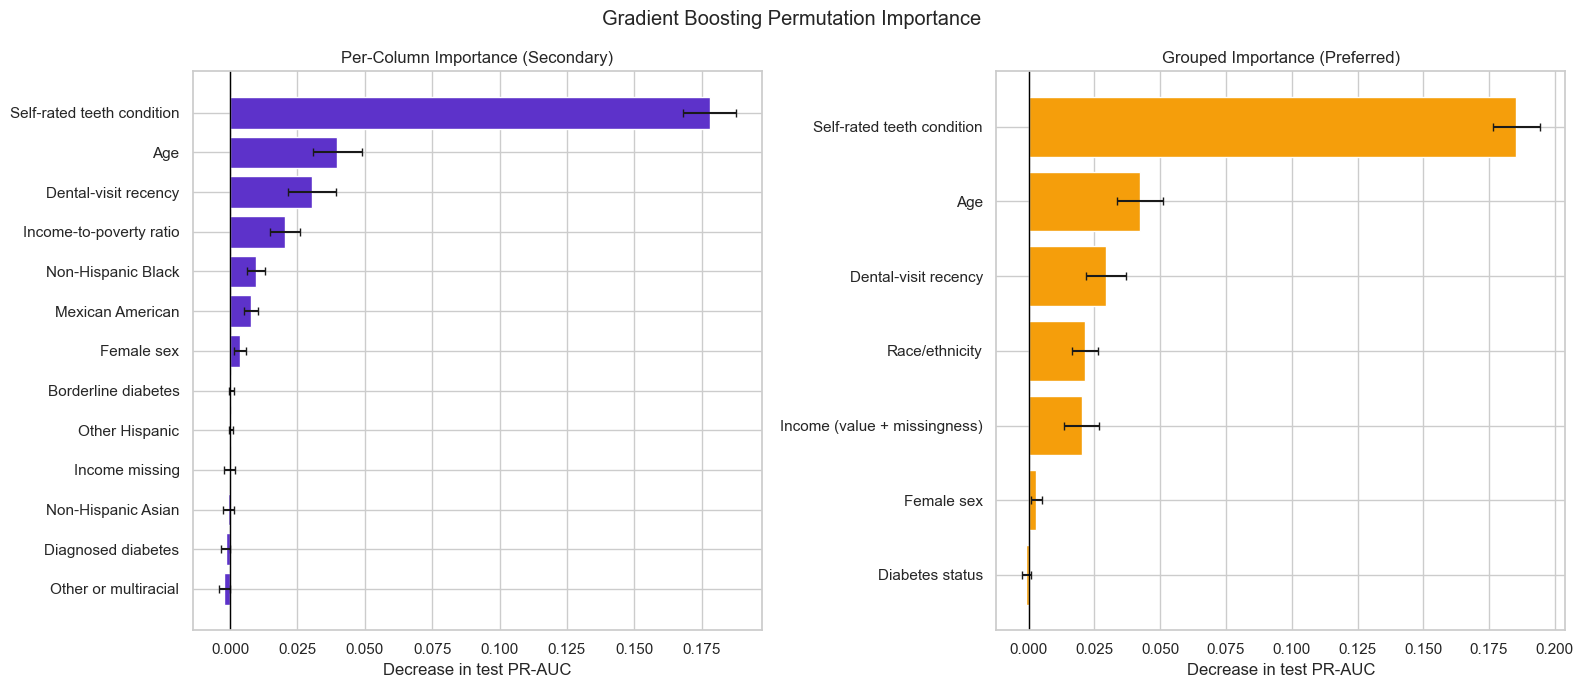

In [12]:
figure, axes = plt.subplots(1, 2, figsize=(16, 7))

column_plot = column_permutation_importance.sort_values(
    "Mean PR-AUC decrease"
)
axes[0].barh(
    column_plot["Readable feature"],
    column_plot["Mean PR-AUC decrease"],
    xerr=column_plot["Permutation SD"],
    color=PURPLE,
    capsize=3,
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Per-Column Importance (Secondary)")
axes[0].set_xlabel("Decrease in test PR-AUC")
axes[0].set_ylabel("")

grouped_plot = grouped_permutation_importance.sort_values(
    "Mean PR-AUC decrease"
)
axes[1].barh(
    grouped_plot["Feature group"],
    grouped_plot["Mean PR-AUC decrease"],
    xerr=grouped_plot["Permutation SD"],
    color=ORANGE,
    capsize=3,
)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Grouped Importance (Preferred)")
axes[1].set_xlabel("Decrease in test PR-AUC")
axes[1].set_ylabel("")

figure.suptitle("Gradient Boosting Permutation Importance")
plt.tight_layout()
plt.show()

In [13]:
top_column = column_permutation_importance.iloc[0]
top_group = grouped_permutation_importance.iloc[0]
race_group_result = grouped_permutation_importance.loc[
    grouped_permutation_importance["Feature group"] == "Race/ethnicity"
].iloc[0]
largest_single_race = column_permutation_importance.loc[
    column_permutation_importance["Feature"].isin(race_features)
].nlargest(1, "Mean PR-AUC decrease").iloc[0]

display(
    Markdown(
        f"The largest per-column decrease is "
        f"**{top_column['Readable feature']} "
        f"({top_column['Mean PR-AUC decrease']:.3f})**. The largest "
        f"coherent grouped decrease is **{top_group['Feature group']} "
        f"({top_group['Mean PR-AUC decrease']:.3f})**. Moving all race "
        f"indicators together changes PR-AUC by "
        f"{race_group_result['Mean PR-AUC decrease']:.3f}, compared "
        f"with {largest_single_race['Mean PR-AUC decrease']:.3f} for "
        f"the largest individual race dummy. The grouped value is the "
        "preferred description because it never creates impossible "
        "race combinations."
    )
)

The largest per-column decrease is **Self-rated teeth condition (0.178)**. The largest coherent grouped decrease is **Self-rated teeth condition (0.185)**. Moving all race indicators together changes PR-AUC by 0.021, compared with 0.010 for the largest individual race dummy. The grouped value is the preferred description because it never creates impossible race combinations.

## SHAP: How Features Move Predictions

Permutation importance ranked the predictors but did not say which way each one points, or how any single participant was scored. SHAP answers both.

Each participant's prediction differs from the cohort average. SHAP splits that difference among the predictors, giving every feature a share of the credit:

`baseline log-odds + all feature contributions = participant log-odds`

The baseline is the model's prediction before any feature information is used, so it sits near the log-odds of cavity prevalence. Adding the thirteen contributions returns that participant's own prediction exactly.

Contributions are reported in log-odds because that is the scale the model adds on. A positive value moves the prediction toward a cavity and a negative value moves it away; the size is how far. A contribution near +0.69 roughly doubles the odds, and one near -0.69 roughly halves them. The same value changes the predicted probability by different amounts depending on the rest of the prediction, so it should not be read as a fixed number of percentage points.

Because the values are calculated per participant, they support three views: averaging the *absolute* contributions ranks the predictors, the beeswarm plot adds direction, and a single participant's contributions explain one prediction.

Correlated predictors share credit, so a contribution describes a feature as used by this model alongside these other features. These explain the model's calculation, not why the participant biologically developed a cavity.

> SHAP is confusing at first. If the explanation above still feels unclear, [SHAP values for beginners](https://www.youtube.com/watch?v=MQ6fFDwjuco) covers the same idea visually and helps.

In [14]:
primary_preprocessor = primary_pipeline.named_steps["preprocessor"]
primary_estimator = primary_pipeline.named_steps["model"]

# The finalized tree pipeline uses median imputation without scaling.
# Confirm that assumption before labeling any SHAP x-axis with the
# original questionnaire values.
assert isinstance(primary_preprocessor, Pipeline)
assert list(primary_preprocessor.named_steps) == ["imputer"]
assert isinstance(
    primary_preprocessor.named_steps["imputer"], SimpleImputer
)

transformed_test = primary_preprocessor.transform(X_test)
transformed_feature_names = (
    primary_preprocessor.get_feature_names_out().tolist()
)
assert transformed_feature_names == feature_columns

# Give the imputed model inputs names immediately. Later plots use this
# DataFrame rather than trusting a numerical column position.
primary_imputed_test = pd.DataFrame(
    transformed_test,
    columns=transformed_feature_names,
    index=X_test.index,
)

shap_explainer = shap.TreeExplainer(primary_estimator)
shap_explanation = shap_explainer(transformed_test)
shap_values = shap_explanation.values

assert shap_values.shape == (len(X_test), len(feature_columns))

reconstructed_log_odds = (
    shap_explanation.base_values + shap_values.sum(axis=1)
)
model_log_odds = primary_estimator.decision_function(transformed_test)

# SHAP values should reconstruct the raw model output. allclose is
# strict enough to catch a real mismatch without failing over harmless
# floating-point noise on another computer.
np.testing.assert_allclose(
    reconstructed_log_odds,
    model_log_odds,
    rtol=1e-5,
    atol=1e-6,
)
maximum_additivity_error = np.max(
    np.abs(reconstructed_log_odds - model_log_odds)
)

shap_global_importance = pd.DataFrame(
    {
        "Feature": feature_columns,
        "Readable feature": [feature_labels[x] for x in feature_columns],
        "Mean absolute SHAP": np.abs(shap_values).mean(axis=0),
        "Mean signed SHAP": shap_values.mean(axis=0),
    }
).sort_values("Mean absolute SHAP", ascending=False)

print(f"Maximum SHAP additivity error: {maximum_additivity_error:.2e}")
shap_global_importance.round(3)

Maximum SHAP additivity error: 7.11e-15


,Feature,Readable feature,Mean absolute SHAP,Mean signed SHAP
3,teeth_condition_ord,Self-rated teeth condition,0.514,0.000
0,age,Age,0.293,0.005
2,dental_visit_recency_ord,Dental-visit recency,0.289,-0.002
1,income_poverty_ratio,Income-to-poverty ratio,0.242,-0.000
9,race_non-hispanic_black,Non-Hispanic Black,0.117,-0.004
4,sex_female,Female sex,0.053,-0.000
12,income_poverty_ratio_missing,Income missing,0.044,0.001
7,race_mexican_american,Mexican American,0.035,-0.001
11,race_other_multi,Other or multiracial,0.031,-0.001
10,race_non-hispanic_asian,Non-Hispanic Asian,0.024,-0.001


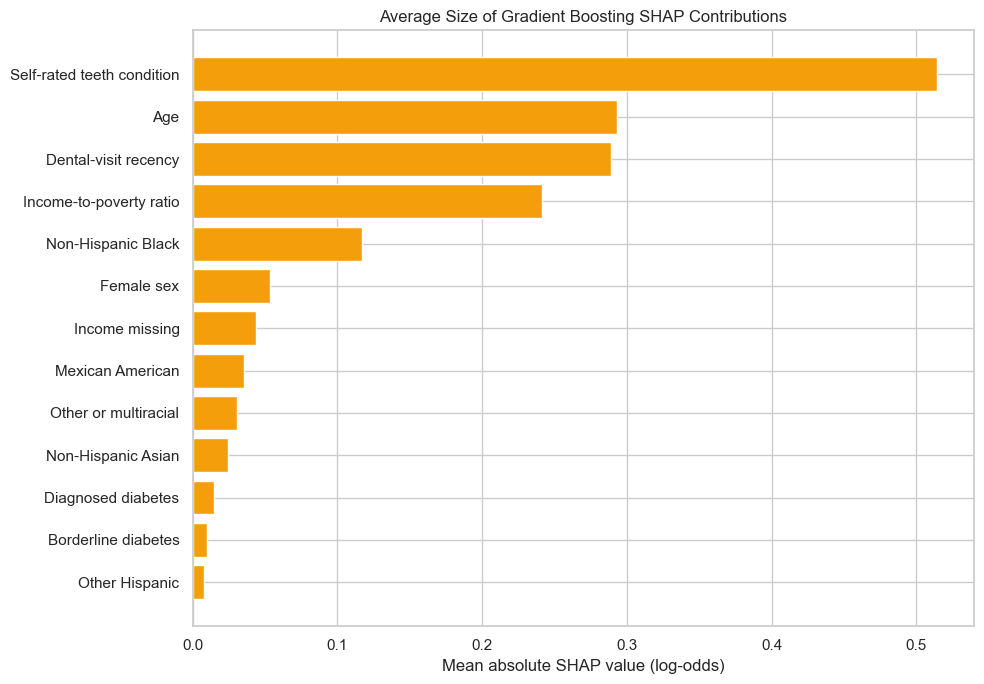

In [15]:
shap_bar = shap_global_importance.sort_values("Mean absolute SHAP")

plt.figure(figsize=(10, 7))
plt.barh(
    shap_bar["Readable feature"],
    shap_bar["Mean absolute SHAP"],
    color=ORANGE,
)
plt.title("Average Size of Gradient Boosting SHAP Contributions")
plt.xlabel("Mean absolute SHAP value (log-odds)")
plt.ylabel("")
plt.tight_layout()
plt.show()

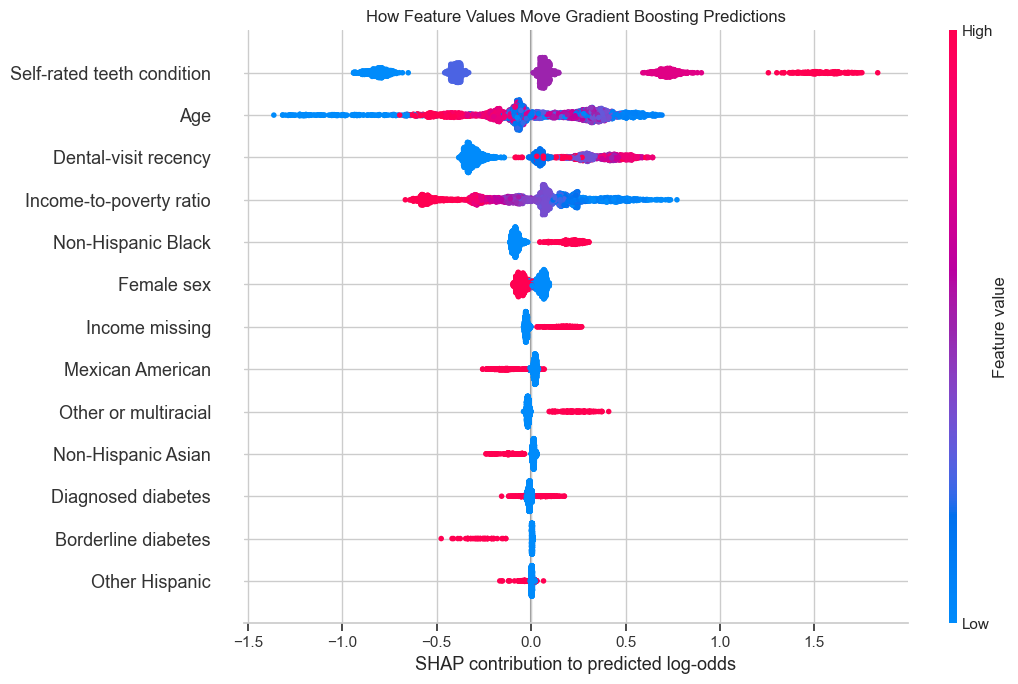

In [16]:
readable_shap = shap.Explanation(
    values=shap_values,
    base_values=shap_explanation.base_values,
    data=transformed_test,
    feature_names=[feature_labels[x] for x in feature_columns],
)

shap.plots.beeswarm(
    readable_shap,
    max_display=len(feature_columns),
    show=False,
    plot_size=(11, 7),
)
plt.title("How Feature Values Move Gradient Boosting Predictions")
plt.xlabel("SHAP contribution to predicted log-odds")
plt.tight_layout()
plt.show()

In [17]:
shap_top_four = shap_global_importance.head(4)

display(
    Markdown(
        "The four largest average SHAP contributions are "
        f"**{', '.join(shap_top_four['Readable feature'])}**. "
        f"The largest is {shap_top_four.iloc[0]['Readable feature']} "
        f"at {shap_top_four.iloc[0]['Mean absolute SHAP']:.3f} "
        "log-odds on average. Absolute SHAP values describe contribution "
        "size; the beeswarm above supplies direction."
    )
)

The four largest average SHAP contributions are **Self-rated teeth condition, Age, Dental-visit recency, Income-to-poverty ratio**. The largest is Self-rated teeth condition at 0.514 log-odds on average. Absolute SHAP values describe contribution size; the beeswarm above supplies direction.

## Looking More Closely at the Four Ordered or Continuous Predictors

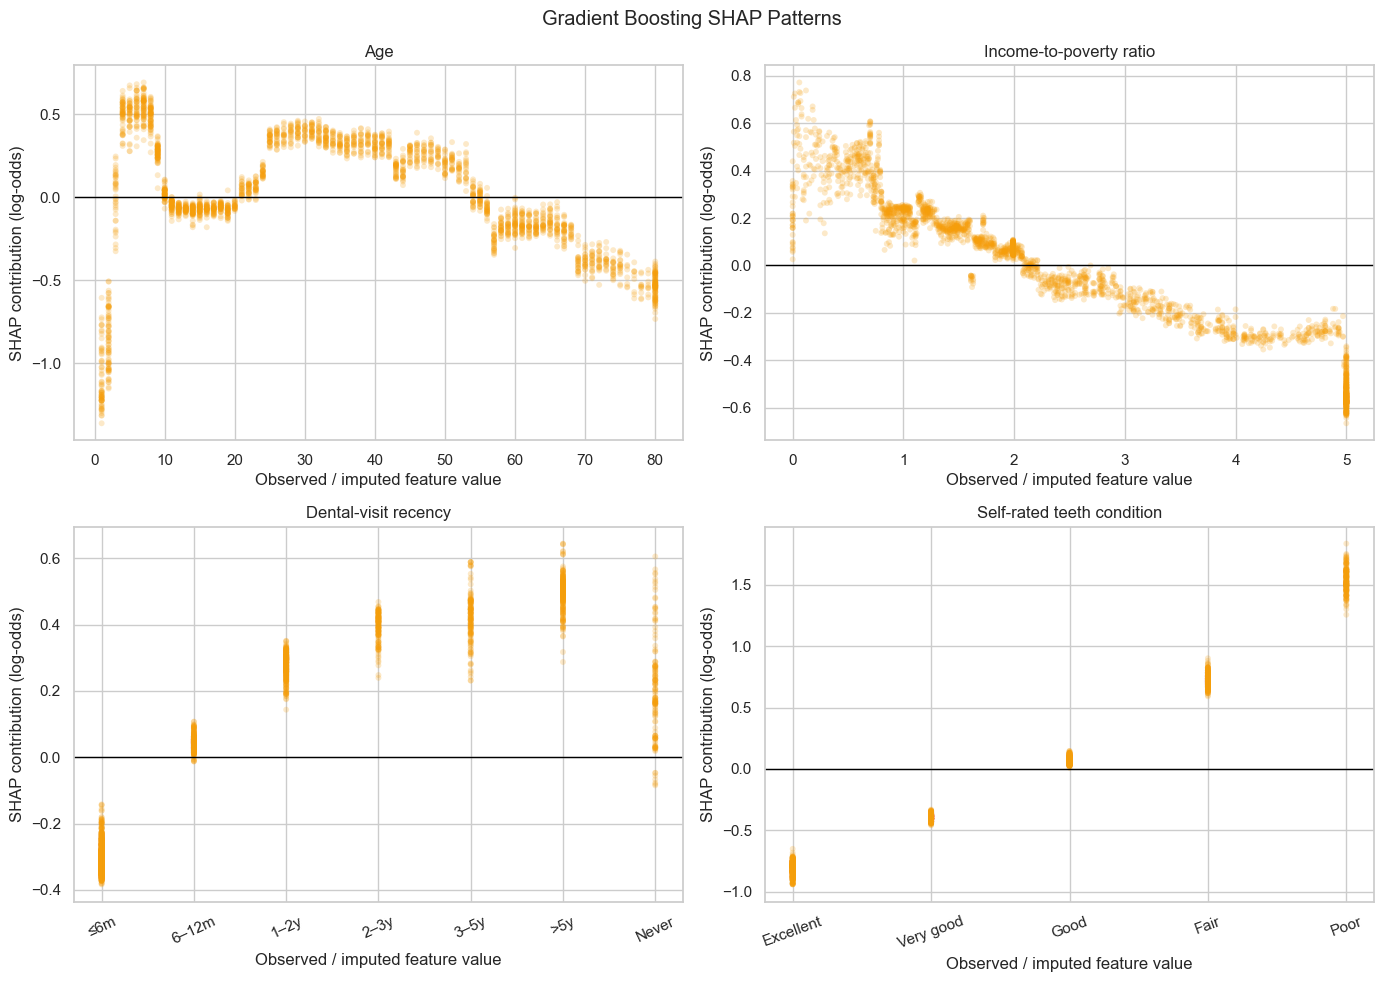

In [18]:
ordered_features = [
    "age",
    "income_poverty_ratio",
    "dental_visit_recency_ord",
    "teeth_condition_ord",
]

figure, axes = plt.subplots(2, 2, figsize=(14, 10))

for axis, feature in zip(axes.flat, ordered_features):
    feature_index = feature_columns.index(feature)
    axis.scatter(
        primary_imputed_test[feature],
        shap_values[:, feature_index],
        color=ORANGE,
        alpha=0.22,
        s=18,
        edgecolor="none",
    )
    axis.axhline(0, color="black", linewidth=1)
    axis.set_title(feature_labels[feature])
    axis.set_xlabel("Observed / imputed feature value")
    axis.set_ylabel("SHAP contribution (log-odds)")

    if feature == "dental_visit_recency_ord":
        axis.set_xticks(
            range(1, 8),
            ["≤6m", "6–12m", "1–2y", "2–3y", "3–5y", ">5y", "Never"],
            rotation=25,
        )
    elif feature == "teeth_condition_ord":
        axis.set_xticks(
            range(1, 6),
            ["Excellent", "Very good", "Good", "Fair", "Poor"],
            rotation=20,
        )

figure.suptitle("Gradient Boosting SHAP Patterns")
plt.tight_layout()
plt.show()

In [19]:
# Summarize the plotted shapes numerically
teeth_index = feature_columns.index("teeth_condition_ord")
visit_index = feature_columns.index("dental_visit_recency_ord")
income_index = feature_columns.index("income_poverty_ratio")
age_index = feature_columns.index("age")

teeth_shap_means = (
    pd.DataFrame(
        {
            "Level": primary_imputed_test["teeth_condition_ord"],
            "SHAP": shap_values[:, teeth_index],
        }
    )
    .groupby("Level")["SHAP"]
    .mean()
)
visit_shap_means = (
    pd.DataFrame(
        {
            "Level": primary_imputed_test["dental_visit_recency_ord"],
            "SHAP": shap_values[:, visit_index],
        }
    )
    .groupby("Level")["SHAP"]
    .mean()
)

income_quintiles = pd.qcut(
    primary_imputed_test["income_poverty_ratio"],
    5,
    duplicates="drop",
)
income_shap_means = (
    pd.DataFrame(
        {"Income group": income_quintiles, "SHAP": shap_values[:, income_index]}
    )
    .groupby("Income group", observed=True)["SHAP"]
    .mean()
)

age_groups = pd.cut(
    primary_imputed_test["age"],
    bins=[0, 12, 18, 35, 50, 65, np.inf],
    labels=["1–11", "12–17", "18–34", "35–49", "50–64", "65+"],
    right=False,
)
age_shap_means = (
    pd.DataFrame({"Age group": age_groups, "SHAP": shap_values[:, age_index]})
    .groupby("Age group", observed=True)["SHAP"]
    .mean()
)

display(
    Markdown(
        "The executed SHAP values show that moving from the best to "
        "worst self-rating changes the mean contribution from "
        f"{teeth_shap_means.iloc[0]:.3f} to "
        f"{teeth_shap_means.iloc[-1]:.3f} log-odds. Dental-visit "
        f"contributions range from {visit_shap_means.min():.3f} to "
        f"{visit_shap_means.max():.3f}, while the lowest and highest "
        "income quintiles average "
        f"{income_shap_means.iloc[0]:.3f} and "
        f"{income_shap_means.iloc[-1]:.3f}. Age is nonlinear: the "
        f"largest mean age contribution occurs in the "
        f"**{age_shap_means.idxmax()}** group and the smallest in the "
        f"**{age_shap_means.idxmin()}** group."
    )
)

The executed SHAP values show that moving from the best to worst self-rating changes the mean contribution from -0.810 to 1.538 log-odds. Dental-visit contributions range from -0.309 to 0.496, while the lowest and highest income quintiles average 0.363 and -0.462. Age is nonlinear: the largest mean age contribution occurs in the **35–49** group and the smallest in the **65+** group.

## Representative Correct and Incorrect Predictions

This section selects the participant closest to the median probability inside each confusion-matrix group. That avoids choosing unusually dramatic or convenient examples.

In [20]:
outcome_group = np.full(len(test_data), "", dtype=object)
actual = y_test.to_numpy()

outcome_group[(actual == 1) & (primary_predictions == 1)] = "True positive"
outcome_group[(actual == 0) & (primary_predictions == 1)] = "False positive"
outcome_group[(actual == 1) & (primary_predictions == 0)] = "False negative"
outcome_group[(actual == 0) & (primary_predictions == 0)] = "True negative"

group_order = [
    "True positive",
    "False positive",
    "False negative",
    "True negative",
]

representative_indices = {}
for group_name in group_order:
    indices = np.flatnonzero(outcome_group == group_name)
    median_probability = np.median(primary_probabilities[indices])
    representative_indices[group_name] = indices[
        np.argmin(
            np.abs(primary_probabilities[indices] - median_probability)
        )
    ]

dental_visit_labels = {
    1: "≤6 months", 2: "6–12 months", 3: "1–2 years",
    4: "2–3 years", 5: "3–5 years", 6: ">5 years", 7: "Never",
}
teeth_condition_labels = {
    1: "Excellent", 2: "Very good", 3: "Good", 4: "Fair", 5: "Poor",
}

representative_rows = []
local_rows = []

for group_name, row_index in representative_indices.items():
    participant = test_data.iloc[row_index]
    model_income = primary_imputed_test.iloc[row_index][
        "income_poverty_ratio"
    ]

    if pd.isna(participant["income_poverty_ratio"]):
        income_display = f"Missing (imputed to {model_income:.2f})"
    else:
        income_display = f"{participant['income_poverty_ratio']:.2f}"

    representative_rows.append(
        {
            "Outcome group": group_name,
            "SEQN": int(participant["SEQN"]),
            "Actual cavity": int(participant[target_column]),
            "Predicted probability": primary_probabilities[row_index],
            "Threshold": primary_threshold,
            "Age": int(participant["age"]),
            "Income used by model": income_display,
            "Last dental visit": dental_visit_labels[
                int(participant["dental_visit_recency_ord"])
            ],
            "Self-rated teeth": teeth_condition_labels[
                int(participant["teeth_condition_ord"])
            ],
        }
    )

    for feature_index, feature in enumerate(feature_columns):
        local_rows.append(
            {
                "Outcome group": group_name,
                "SEQN": int(participant["SEQN"]),
                "Feature": feature,
                "Readable feature": feature_labels[feature],
                "SHAP contribution": shap_values[row_index, feature_index],
            }
        )

representative_cases = pd.DataFrame(representative_rows)
local_contributions = pd.DataFrame(local_rows)
representative_cases.round(
    {"Predicted probability": 3, "Threshold": 3}
)

,Outcome group,SEQN,Actual cavity,Predicted probability,Threshold,Age,Income used by model,Last dental visit,Self-rated teeth
0,True positive,114135,1,0.337,0.13,21,Missing (imputed to 1.99),≤6 months,Fair
1,False positive,124660,0,0.219,0.13,52,Missing (imputed to 1.99),1–2 years,Good
2,False negative,111800,1,0.085,0.13,58,3.92,≤6 months,Good
3,True negative,109478,0,0.069,0.13,27,5.00,6–12 months,Very good


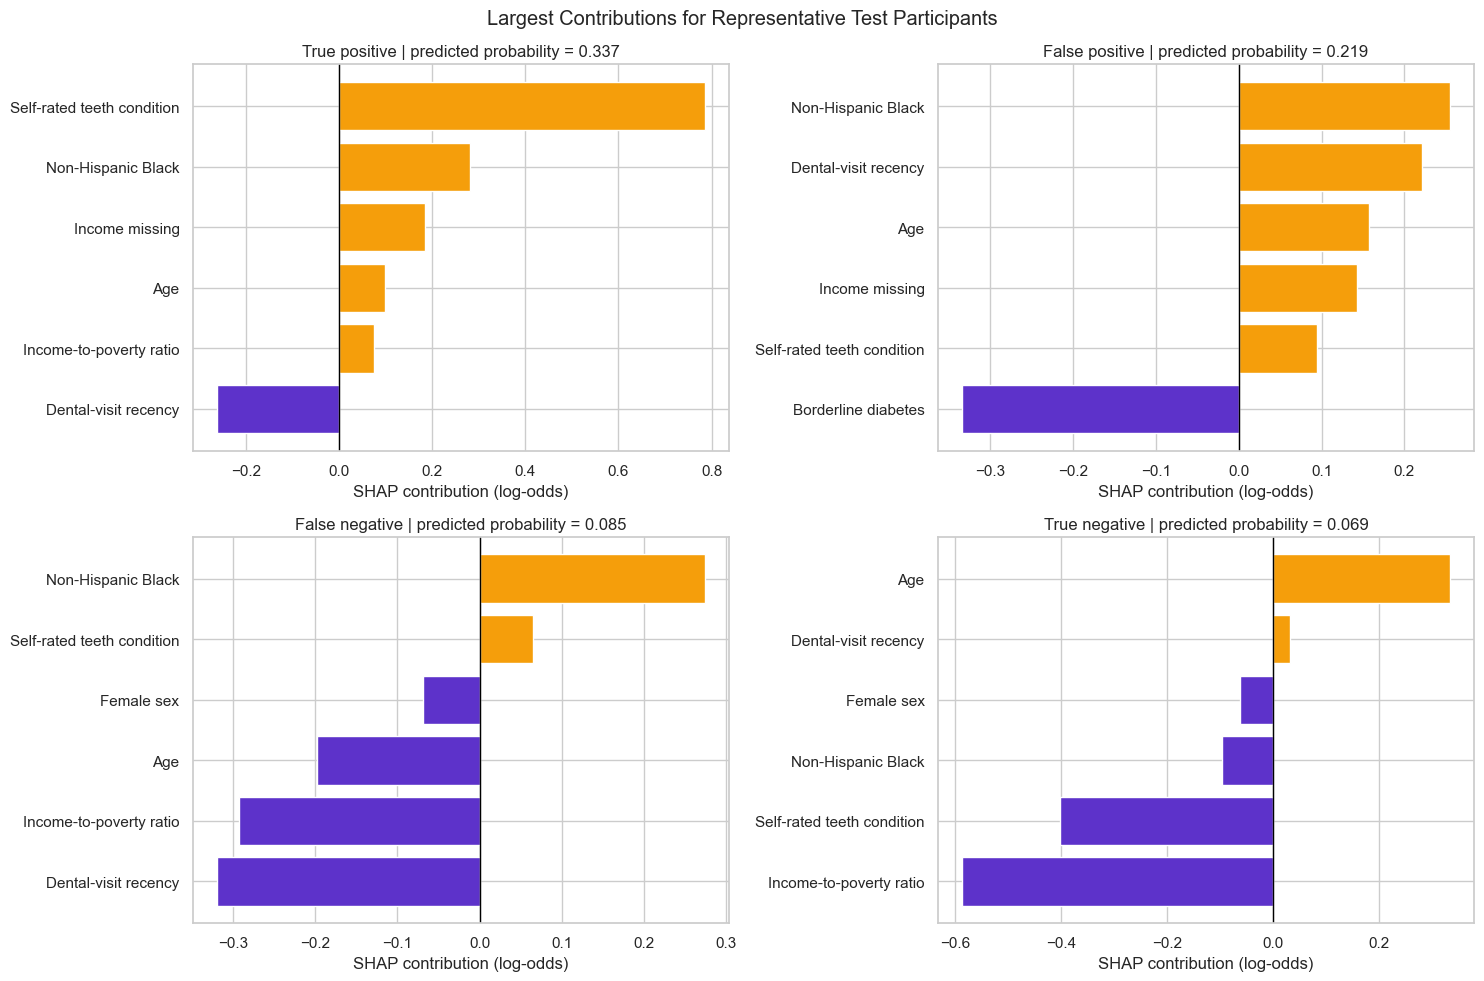

In [21]:
figure, axes = plt.subplots(2, 2, figsize=(15, 10))

for axis, group_name in zip(axes.flat, group_order):
    case_data = local_contributions.loc[
        local_contributions["Outcome group"] == group_name
    ].copy()
    case_data["Absolute contribution"] = (
        case_data["SHAP contribution"].abs()
    )
    case_data = (
        case_data.nlargest(6, "Absolute contribution")
        .sort_values("SHAP contribution")
    )
    colors = np.where(
        case_data["SHAP contribution"] >= 0, ORANGE, PURPLE
    )

    axis.barh(
        case_data["Readable feature"],
        case_data["SHAP contribution"],
        color=colors,
    )
    axis.axvline(0, color="black", linewidth=1)

    probability = representative_cases.loc[
        representative_cases["Outcome group"] == group_name,
        "Predicted probability",
    ].iloc[0]
    axis.set_title(
        f"{group_name} | predicted probability = {probability:.3f}"
    )
    axis.set_xlabel("SHAP contribution (log-odds)")
    axis.set_ylabel("")

figure.suptitle(
    "Largest Contributions for Representative Test Participants"
)
plt.tight_layout()
plt.show()

In [22]:
def largest_local_contributor(group_name):
    group_rows = local_contributions.loc[
        local_contributions["Outcome group"] == group_name
    ].copy()
    row = group_rows.loc[
        group_rows["SHAP contribution"].abs().idxmax()
    ]
    return row["Readable feature"], row["SHAP contribution"]


true_positive_feature, true_positive_value = largest_local_contributor(
    "True positive"
)
false_negative_feature, false_negative_value = largest_local_contributor(
    "False negative"
)
false_negative_probability = representative_cases.loc[
    representative_cases["Outcome group"] == "False negative",
    "Predicted probability",
].iloc[0]

display(
    Markdown(
        f"The representative true positive's largest contribution is "
        f"**{true_positive_feature} ({true_positive_value:+.3f})**. "
        f"The representative false negative receives its largest "
        f"contribution from **{false_negative_feature} "
        f"({false_negative_value:+.3f})** and remains below the frozen "
        f"threshold at probability {false_negative_probability:.3f}. "
        "This is why a low screening probability cannot rule out an "
        "untreated cavity."
    )
)

The representative true positive's largest contribution is **Self-rated teeth condition (+0.785)**. The representative false negative receives its largest contribution from **Dental-visit recency (-0.319)** and remains below the frozen threshold at probability 0.085. This is why a low screening probability cannot rule out an untreated cavity.

### What the Four Cases Show

In both correct predictions the self-rating points the right way: it is the largest single contribution for the true positive, and a clear downward push for the true negative.

In both errors it sits in the middle of its scale and contributes almost nothing. That leaves age, income, and dental-visit recency to decide the prediction, and those describe **access to dental care rather than the condition of a participant's teeth**. It is what produced the representative false negative: a recent visit and a higher income each push the prediction down, and the participant still had an untreated cavity.

Leaning on access is the cost of a questionnaire-only screening model. It sees what a participant reports, and reported access is not the same as oral health. These are four individual participants rather than evidence about every error, but the pattern is consistent with the threshold analysis: a low predicted probability cannot rule out an untreated cavity.

## Three Preplanned Sensitivity Analyses

The following checks were specified before interpreting the final model:

1. **Without self-rated teeth condition:** tests how much performance comes from participants already recognizing an oral-health problem.
2. **Without race/ethnicity:** tests whether the model's overall ranking depends on the five race/ethnicity indicators.
3. **Complete-income participants:** compares the full imputed cohort with participants who reported income.

The first two are paired comparisons: the full and reduced models use the exact same participants and validation folds. The complete-income analysis uses a smaller cohort and new stratified folds, so its difference also reflects sample composition and must not be described as the pure effect of imputation.

Every sensitivity pipeline below is rebuilt with an explicit, name-based `ColumnTransformer`. This prevents a removed feature from silently shifting another column into its position. The fitted primary model, frozen threshold, and permanent test set remain unchanged.

In [23]:
sensitivity_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)
sensitivity_scoring = {
    "PR-AUC": "average_precision",
    "ROC-AUC": "roc_auc",
}


def build_sensitivity_pipeline(selected_features):
    '''
    Rebuild gradient boosting with explicit name-based feature selection.

    The estimator keeps the already-selected Notebook 4 hyperparameters,
    but every sensitivity model is fitted from scratch inside each fold.
    '''
    selected_features = list(selected_features)

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "selected",
                SimpleImputer(strategy="median"),
                selected_features,
            )
        ],
        remainder="drop",
        verbose_feature_names_out=False,
    )

    pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", clone(primary_estimator)),
        ]
    )

    configured_columns = list(
        pipeline.named_steps["preprocessor"].transformers[0][2]
    )
    assert configured_columns == selected_features
    assert len(configured_columns) == len(set(configured_columns))
    return pipeline


self_rating_feature = "teeth_condition_ord"
no_self_rating_features = [
    feature for feature in feature_columns
    if feature != self_rating_feature
]
no_race_features = [
    feature for feature in feature_columns
    if feature not in race_features
]
complete_income_features = [
    feature for feature in feature_columns
    if feature != "income_poverty_ratio_missing"
]

assert self_rating_feature not in no_self_rating_features
assert not set(race_features).intersection(no_race_features)
assert "income_poverty_ratio_missing" not in complete_income_features

# Materialize the fold indices once so the full, no-self-rating, and
# no-race models are evaluated on identical participants in each fold.
paired_cv_splits = list(sensitivity_cv.split(X_train, y_train))

print("Cross-validating all 13 predictors...")
full_scores = cross_validate(
    build_sensitivity_pipeline(feature_columns),
    X_train,
    y_train,
    cv=paired_cv_splits,
    scoring=sensitivity_scoring,
    n_jobs=-1,
    error_score="raise",
)

print("Cross-validating without self-rated teeth condition...")
no_self_rating_scores = cross_validate(
    build_sensitivity_pipeline(no_self_rating_features),
    X_train,
    y_train,
    cv=paired_cv_splits,
    scoring=sensitivity_scoring,
    n_jobs=-1,
    error_score="raise",
)

print("Cross-validating without race/ethnicity...")
no_race_scores = cross_validate(
    build_sensitivity_pipeline(no_race_features),
    X_train,
    y_train,
    cv=paired_cv_splits,
    scoring=sensitivity_scoring,
    n_jobs=-1,
    error_score="raise",
)

complete_income_mask = X_train["income_poverty_ratio"].notna()
X_complete_income = X_train.loc[
    complete_income_mask, complete_income_features
].copy()
y_complete_income = y_train.loc[complete_income_mask].copy()

assert X_complete_income["income_poverty_ratio"].notna().all()
assert (
    X_train.loc[
        complete_income_mask,
        "income_poverty_ratio_missing",
    ] == 0
).all()

complete_income_cv_splits = list(
    sensitivity_cv.split(X_complete_income, y_complete_income)
)

print("Cross-validating complete-income participants...")
complete_income_scores = cross_validate(
    build_sensitivity_pipeline(complete_income_features),
    X_complete_income,
    y_complete_income,
    cv=complete_income_cv_splits,
    scoring=sensitivity_scoring,
    n_jobs=-1,
    error_score="raise",
)

# Reproduce Notebook 4's saved development estimate. This catches a
# preprocessing or fold-definition mismatch before interpreting any
# sensitivity difference.
stored_development_row = development_results.loc[
    development_results["Model"] == primary_model
].iloc[0]
stored_development_pr_auc = stored_development_row[
    "average_precision_mean"
]
np.testing.assert_allclose(
    full_scores["test_PR-AUC"].mean(),
    stored_development_pr_auc,
    atol=0.005,
    rtol=0,
)

sensitivity_fold_results = pd.DataFrame(
    {
        "Fold": np.arange(1, 6),
        "Full cohort PR-AUC": full_scores["test_PR-AUC"],
        "Without self-rating PR-AUC": (
            no_self_rating_scores["test_PR-AUC"]
        ),
        "Without race PR-AUC": no_race_scores["test_PR-AUC"],
        "Complete-income PR-AUC (separate cohort)": (
            complete_income_scores["test_PR-AUC"]
        ),
        "Full cohort ROC-AUC": full_scores["test_ROC-AUC"],
        "Without self-rating ROC-AUC": (
            no_self_rating_scores["test_ROC-AUC"]
        ),
        "Without race ROC-AUC": no_race_scores["test_ROC-AUC"],
        "Complete-income ROC-AUC (separate cohort)": (
            complete_income_scores["test_ROC-AUC"]
        ),
    }
)

# These differences are paired because both models saw the same
# validation participants in every fold.
sensitivity_fold_results["Self-rating PR-AUC difference"] = (
    sensitivity_fold_results["Full cohort PR-AUC"]
    - sensitivity_fold_results["Without self-rating PR-AUC"]
)
sensitivity_fold_results["Race PR-AUC difference"] = (
    sensitivity_fold_results["Full cohort PR-AUC"]
    - sensitivity_fold_results["Without race PR-AUC"]
)

Cross-validating all 13 predictors...
Cross-validating without self-rated teeth condition...
Cross-validating without race/ethnicity...
Cross-validating complete-income participants...


In [24]:
def summarize_cv(label, scores, participants, cohort):
    return {
        "Analysis": label,
        "Cohort": cohort,
        "Participants": participants,
        "Mean PR-AUC": scores["test_PR-AUC"].mean(),
        "PR-AUC SD": scores["test_PR-AUC"].std(ddof=1),
        "Mean ROC-AUC": scores["test_ROC-AUC"].mean(),
        "ROC-AUC SD": scores["test_ROC-AUC"].std(ddof=1),
    }


sensitivity_summary = pd.DataFrame(
    [
        summarize_cv(
            "All 13 predictors",
            full_scores,
            len(X_train),
            "Full imputed training cohort",
        ),
        summarize_cv(
            "Without self-rated teeth condition",
            no_self_rating_scores,
            len(X_train),
            "Full imputed training cohort",
        ),
        summarize_cv(
            "Without race/ethnicity",
            no_race_scores,
            len(X_train),
            "Full imputed training cohort",
        ),
        summarize_cv(
            "Complete-income participants",
            complete_income_scores,
            len(X_complete_income),
            "Reported-income participants only",
        ),
    ]
)

paired_difference_rows = []
for sensitivity_name, difference_column in {
    "Remove self-rated teeth condition": (
        "Self-rating PR-AUC difference"
    ),
    "Remove race/ethnicity": "Race PR-AUC difference",
}.items():
    differences = sensitivity_fold_results[difference_column]
    paired_difference_rows.append(
        {
            "Paired comparison": sensitivity_name,
            "Mean PR-AUC difference": differences.mean(),
            "Difference SD": differences.std(ddof=1),
            "Minimum fold difference": differences.min(),
            "Maximum fold difference": differences.max(),
            "Folds where full model scored higher": int(
                (differences > 0).sum()
            ),
        }
    )

paired_sensitivity_summary = pd.DataFrame(paired_difference_rows)

display(sensitivity_summary.round(3))
display(paired_sensitivity_summary.round(3))
sensitivity_fold_results.round(3)

,Analysis,Cohort,Participants,Mean PR-AUC,PR-AUC SD,Mean ROC-AUC,ROC-AUC SD
0,All 13 predictors,Full imputed training cohort,10572,0.430,0.046,0.762,0.018
1,Without self-rated teeth condition,Full imputed training cohort,10572,0.352,0.034,0.718,0.023
2,Without race/ethnicity,Full imputed training cohort,10572,0.423,0.038,0.756,0.016
3,Complete-income participants,Reported-income participants only,9223,0.430,0.030,0.766,0.012


,Paired comparison,Mean PR-AUC difference,Difference SD,Minimum fold difference,Maximum fold difference,Folds where full model scored higher
0,Remove self-rated teeth condition,0.079,0.017,0.060,0.099,5
1,Remove race/ethnicity,0.007,0.012,-0.008,0.020,3


,Fold,Full cohort PR-AUC,Without self-rating PR-AUC,Without race PR-AUC,Complete-income PR-AUC (separate cohort),Full cohort ROC-AUC,Without self-rating ROC-AUC,Without race ROC-AUC,Complete-income ROC-AUC (separate cohort),Self-rating PR-AUC difference,Race PR-AUC difference
0,1,0.453,0.376,0.446,0.394,0.773,0.731,0.767,0.751,0.077,0.007
1,2,0.418,0.326,0.400,0.441,0.759,0.708,0.749,0.776,0.093,0.018
2,3,0.497,0.398,0.477,0.448,0.787,0.752,0.779,0.781,0.099,0.020
3,4,0.379,0.319,0.387,0.463,0.742,0.695,0.744,0.767,0.060,-0.008
4,5,0.404,0.340,0.405,0.403,0.747,0.705,0.743,0.757,0.064,-0.001


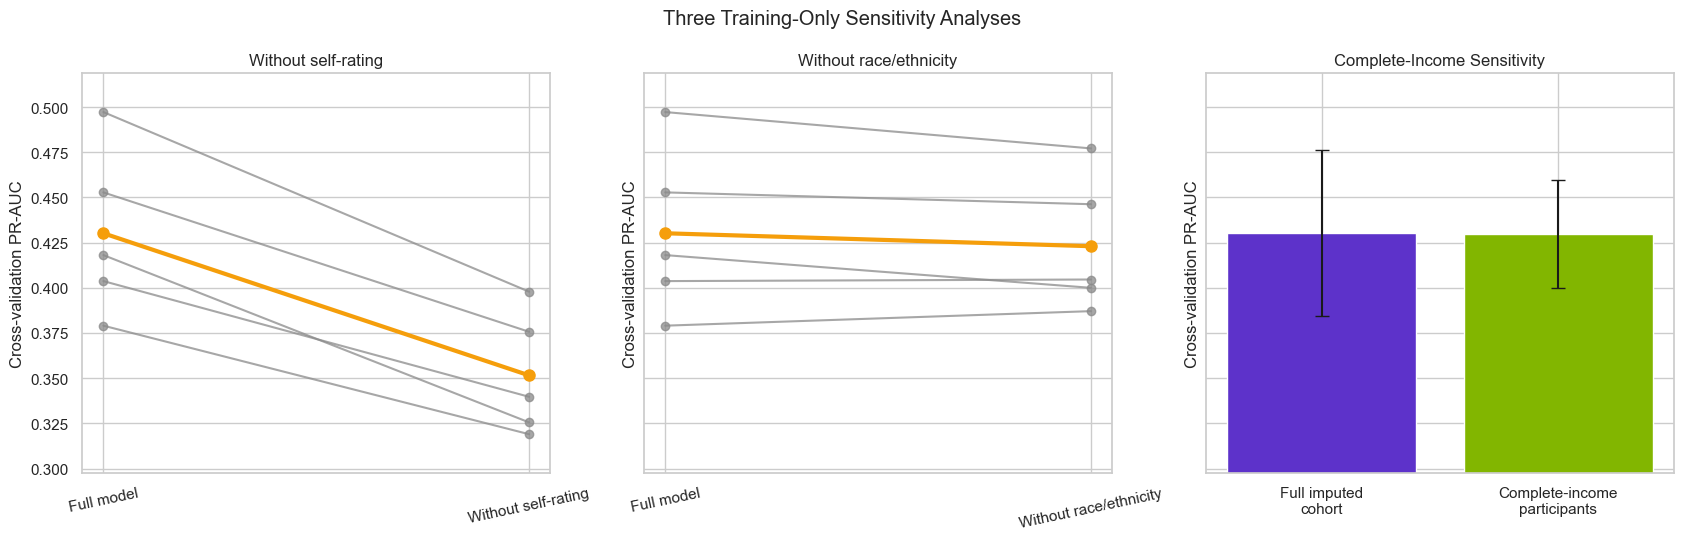

In [25]:
figure, axes = plt.subplots(1, 3, figsize=(17, 5.5), sharey=True)

plotted_pr_auc_values = np.concatenate(
    [
        full_scores["test_PR-AUC"],
        no_self_rating_scores["test_PR-AUC"],
        no_race_scores["test_PR-AUC"],
        complete_income_scores["test_PR-AUC"],
    ]
)
plot_padding = max(0.02, np.ptp(plotted_pr_auc_values) * 0.12)
y_limits = (
    plotted_pr_auc_values.min() - plot_padding,
    plotted_pr_auc_values.max() + plot_padding,
)

paired_plot_specs = [
    (
        axes[0],
        "Without self-rating",
        no_self_rating_scores["test_PR-AUC"],
    ),
    (
        axes[1],
        "Without race/ethnicity",
        no_race_scores["test_PR-AUC"],
    ),
]

for axis, reduced_label, reduced_values in paired_plot_specs:
    for fold_number in range(5):
        axis.plot(
            ["Full model", reduced_label],
            [
                full_scores["test_PR-AUC"][fold_number],
                reduced_values[fold_number],
            ],
            color=GRAY,
            alpha=0.75,
            marker="o",
        )

    mean_values = [
        full_scores["test_PR-AUC"].mean(),
        reduced_values.mean(),
    ]
    axis.plot(
        ["Full model", reduced_label],
        mean_values,
        color=ORANGE,
        marker="o",
        linewidth=3,
        markersize=8,
    )
    axis.set_title(reduced_label)
    axis.set_ylabel("Cross-validation PR-AUC")
    axis.set_ylim(y_limits)
    axis.tick_params(axis="x", rotation=12)

# Complete-income folds contain different participants, so connecting
# fold numbers would falsely suggest a paired comparison.
complete_means = [
    full_scores["test_PR-AUC"].mean(),
    complete_income_scores["test_PR-AUC"].mean(),
]
complete_sds = [
    full_scores["test_PR-AUC"].std(ddof=1),
    complete_income_scores["test_PR-AUC"].std(ddof=1),
]
axes[2].bar(
    ["Full imputed\ncohort", "Complete-income\nparticipants"],
    complete_means,
    yerr=complete_sds,
    color=[PURPLE, GREEN],
    capsize=5,
)
axes[2].set_title("Complete-Income Sensitivity")
axes[2].set_ylabel("Cross-validation PR-AUC")
axes[2].set_ylim(y_limits)

figure.suptitle("Three Training-Only Sensitivity Analyses")
plt.tight_layout()
plt.show()

In [26]:
full_pr = full_scores["test_PR-AUC"].mean()
no_self_pr = no_self_rating_scores["test_PR-AUC"].mean()
no_race_pr = no_race_scores["test_PR-AUC"].mean()
complete_pr = complete_income_scores["test_PR-AUC"].mean()

self_difference = paired_sensitivity_summary.loc[
    paired_sensitivity_summary["Paired comparison"]
    == "Remove self-rated teeth condition"
].iloc[0]
race_difference = paired_sensitivity_summary.loc[
    paired_sensitivity_summary["Paired comparison"]
    == "Remove race/ethnicity"
].iloc[0]


def paired_row(label, reduced_mean, difference_row):
    """
    Format one paired comparison as a table row.

    The change column is reduced minus full, so a negative number means
    performance dropped once the feature was removed.
    """
    return (
        f"| {label} | {reduced_mean:.3f} "
        f"| {reduced_mean - full_pr:+.3f} "
        f"| {difference_row['Difference SD']:.3f} "
        f"| {int(difference_row['Folds where full model scored higher'])} of 5 |"
    )


results_table = "\n".join(
    [
        "| Model | Mean PR-AUC | Change vs full | Fold SD | Folds full model led |",
        "|---|---|---|---|---|",
        f"| All 13 predictors | {full_pr:.3f} | — | — | — |",
        paired_row(
            "Without self-rated teeth condition",
            no_self_pr,
            self_difference,
        ),
        paired_row("Without race/ethnicity", no_race_pr, race_difference),
        f"| Complete-income participants "
        f"({len(X_complete_income):,} people) | {complete_pr:.3f} "
        f"| not comparable | — | — |",
    ]
)

reading_notes = "\n".join(
    [
        "**How to read this**",
        "",
        "- **Change vs full** is the reduced model minus the full model. "
        "A negative value means removing that feature made the model worse.",
        "- **Fold SD** is the spread of the paired per-fold differences. "
        "It is descriptive only: cross-validation folds reuse the same "
        "training data, so they are not independent observations and no "
        "p-value or confidence interval is implied.",
        "- **Folds full model led** counts how many of the five folds the "
        "full model scored higher in. Five of five is a consistent effect; "
        "a split result is not.",
        "- **The last row is not a paired comparison.** It uses a smaller "
        "cohort with its own folds, so its difference reflects both "
        "imputation and a change in who is in the sample. It cannot "
        "isolate the effect of imputation.",
    ]
)

display(Markdown(results_table + "\n\n" + reading_notes))

| Model | Mean PR-AUC | Change vs full | Fold SD | Folds full model led |
|---|---|---|---|---|
| All 13 predictors | 0.430 | — | — | — |
| Without self-rated teeth condition | 0.352 | -0.079 | 0.017 | 5 of 5 |
| Without race/ethnicity | 0.423 | -0.007 | 0.012 | 3 of 5 |
| Complete-income participants (9,223 people) | 0.430 | not comparable | — | — |

**How to read this**

- **Change vs full** is the reduced model minus the full model. A negative value means removing that feature made the model worse.
- **Fold SD** is the spread of the paired per-fold differences. It is descriptive only: cross-validation folds reuse the same training data, so they are not independent observations and no p-value or confidence interval is implied.
- **Folds full model led** counts how many of the five folds the full model scored higher in. Five of five is a consistent effect; a split result is not.
- **The last row is not a paired comparison.** It uses a smaller cohort with its own folds, so its difference reflects both imputation and a change in who is in the sample. It cannot isolate the effect of imputation.

## What the Self-Rating Result Means for Deployment

The clearest description is that this model largely formalizes:

> Ask people how their teeth are, then adjust that answer using age, dental-visit recency, income, and the remaining participant characteristics.

That is not automatically a weakness. For **pre-examination screening**, self-rating is available at the correct time and can help prioritize who should receive an examination or referral. For a scientific claim that the model discovers cavities independently of participant awareness, however, the feature is too close to the outcome.

## Comparing the Interpretation Methods

No method is complete by itself. Agreement across split importance, permutation importance, and SHAP provides a more stable description of what the primary model uses.

In [27]:
logistic_lookup = logistic_coefficients.set_index("Feature")
rf_lookup = tree_importances.loc[
    tree_importances["Model"] == "Random Forest"
].set_index("Feature")
gb_lookup = tree_importances.loc[
    tree_importances["Model"] == "Gradient Boosting"
].set_index("Feature")
column_permutation_lookup = column_permutation_importance.set_index(
    "Feature"
)
shap_lookup = shap_global_importance.set_index("Feature")

combined_interpretation = pd.DataFrame(
    {
        "Feature": feature_columns,
        "Readable feature": [feature_labels[x] for x in feature_columns],
        "Logistic coefficient": [
            logistic_lookup.loc[x, "Coefficient"] for x in feature_columns
        ],
        "Logistic odds ratio": [
            logistic_lookup.loc[x, "Odds ratio"] for x in feature_columns
        ],
        "Random forest split importance": [
            rf_lookup.loc[x, "Split importance"] for x in feature_columns
        ],
        "Gradient boosting split importance": [
            gb_lookup.loc[x, "Split importance"] for x in feature_columns
        ],
        "Per-column PR-AUC decrease": [
            column_permutation_lookup.loc[x, "Mean PR-AUC decrease"]
            for x in feature_columns
        ],
        "Mean absolute SHAP": [
            shap_lookup.loc[x, "Mean absolute SHAP"]
            for x in feature_columns
        ],
    }
)

rank_sources = {
    "Gradient boosting split importance": "Split rank",
    "Per-column PR-AUC decrease": "Per-column permutation rank",
    "Mean absolute SHAP": "SHAP rank",
}
for value_column, rank_column in rank_sources.items():
    combined_interpretation[rank_column] = (
        combined_interpretation[value_column]
        .rank(ascending=False, method="min")
        .astype(int)
    )

rank_columns = list(rank_sources.values())
combined_interpretation["Average feature-level rank"] = (
    combined_interpretation[rank_columns].mean(axis=1)
)
combined_interpretation = combined_interpretation.sort_values(
    ["Average feature-level rank", "SHAP rank"]
).reset_index(drop=True)

print("Feature-level comparison:")
display(combined_interpretation.round(3))
print(
    "Grouped permutation is the preferred performance-dependence "
    "result for race, diabetes, and income:"
)
grouped_permutation_importance.round(3)

Feature-level comparison:


,Feature,Readable feature,Logistic coefficient,Logistic odds ratio,Random forest split importance,Gradient boosting split importance,Per-column PR-AUC decrease,Mean absolute SHAP,Split rank,Per-column permutation rank,SHAP rank,Average feature-level rank
0,teeth_condition_ord,Self-rated teeth condition,0.770,2.159,0.248,0.476,0.178,0.514,1,1,1,1.000
1,age,Age,-0.137,0.872,0.257,0.155,0.040,0.293,2,2,2,2.000
2,dental_visit_recency_ord,Dental-visit recency,0.217,1.242,0.127,0.152,0.030,0.289,3,3,3,3.000
3,income_poverty_ratio,Income-to-poverty ratio,-0.277,0.758,0.237,0.134,0.020,0.242,4,4,4,4.000
4,race_non-hispanic_black,Non-Hispanic Black,0.258,1.294,0.027,0.029,0.010,0.117,5,5,5,5.000
5,sex_female,Female sex,-0.118,0.889,0.028,0.008,0.004,0.053,8,7,6,7.000
6,race_mexican_american,Mexican American,-0.201,0.818,0.016,0.010,0.008,0.035,7,6,8,7.000
7,income_poverty_ratio_missing,Income missing,0.152,1.165,0.014,0.005,-0.000,0.044,10,10,7,9.000
8,race_other_multi,Other or multiracial,0.213,1.238,0.011,0.011,-0.002,0.031,6,13,9,9.333
9,race_non-hispanic_asian,Non-Hispanic Asian,-0.132,0.876,0.010,0.005,-0.001,0.024,11,11,10,10.667


Grouped permutation is the preferred performance-dependence result for race, diabetes, and income:


,Feature group,Columns moved together,Mean PR-AUC decrease,Permutation SD,2.5th percentile,97.5th percentile
5,Self-rated teeth condition,teeth_condition_ord,0.185,0.009,0.169,0.201
3,Age,age,0.042,0.009,0.029,0.058
4,Dental-visit recency,dental_visit_recency_ord,0.030,0.008,0.017,0.043
0,Race/ethnicity,"race_mexican_american, race_other_hispanic, race_non-hispanic_black, race_non-hispanic_asian, race_other_multi",0.021,0.005,0.015,0.031
2,Income (value + missingness),"income_poverty_ratio, income_poverty_ratio_missing",0.020,0.007,0.008,0.034
6,Female sex,sex_female,0.003,0.002,0.000,0.007
1,Diabetes status,"diabetes_yes, diabetes_borderline",-0.001,0.002,-0.005,0.002


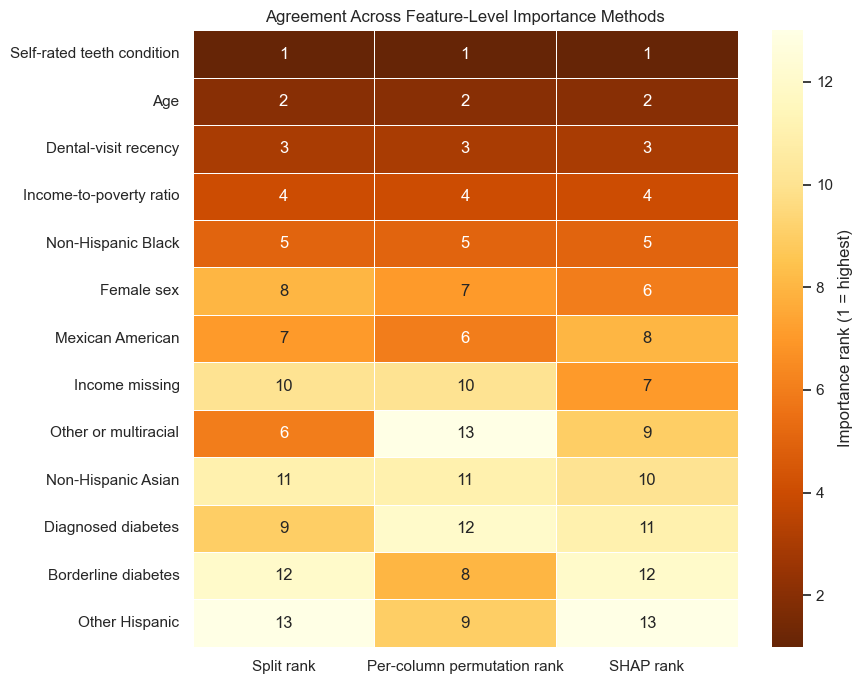

In [28]:
rank_heatmap = combined_interpretation.set_index(
    "Readable feature"
)[rank_columns]

plt.figure(figsize=(9, 7))
sns.heatmap(
    rank_heatmap,
    annot=True,
    fmt="d",
    cmap="YlOrBr_r",
    cbar_kws={"label": "Importance rank (1 = highest)"},
    linewidths=0.5,
)
plt.title("Agreement Across Feature-Level Importance Methods")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [29]:
method_top_features = {
    "split importance": combined_interpretation.nsmallest(
        4, "Split rank"
    )["Readable feature"].tolist(),
    "per-column permutation": combined_interpretation.nsmallest(
        4, "Per-column permutation rank"
    )["Readable feature"].tolist(),
    "SHAP": combined_interpretation.nsmallest(
        4, "SHAP rank"
    )["Readable feature"].tolist(),
}
shared_top_features = set.intersection(
    *[set(values) for values in method_top_features.values()]
)

display(
    Markdown(
        f"The features appearing in every method's top four are "
        f"**{', '.join(sorted(shared_top_features))}**. This agreement "
        "makes the descriptive interpretation more stable, but the "
        "grouped permutation table remains the preferred basis for "
        "claims about race, diabetes, and income because it preserves "
        "their valid encoding."
    )
)

The features appearing in every method's top four are **Age, Dental-visit recency, Income-to-poverty ratio, Self-rated teeth condition**. This agreement makes the descriptive interpretation more stable, but the grouped permutation table remains the preferred basis for claims about race, diabetes, and income because it preserves their valid encoding.

## Saving the Interpretation Artifacts

The notebook saves separate per-column and grouped permutation tables so their different purposes remain clear. It also saves the sensitivity summary, fold-level results, and paired differences instead of reducing all three analyses to one number.

In [30]:
FEATURE_INTERPRETATION_PATH = (
    TABLE_FOLDER / "model_feature_interpretation.csv"
)
COLUMN_PERMUTATION_PATH = (
    TABLE_FOLDER / "model_permutation_importance_columns.csv"
)
GROUPED_PERMUTATION_PATH = (
    TABLE_FOLDER / "model_permutation_importance_groups.csv"
)
SHAP_VALUES_PATH = TABLE_FOLDER / "model_shap_values.csv"
LOCAL_CASES_PATH = TABLE_FOLDER / "model_interpretation_cases.csv"
SENSITIVITY_SUMMARY_PATH = (
    TABLE_FOLDER / "model_sensitivity_summary.csv"
)
SENSITIVITY_FOLDS_PATH = (
    TABLE_FOLDER / "model_sensitivity_fold_results.csv"
)
SENSITIVITY_DIFFERENCES_PATH = (
    TABLE_FOLDER / "model_sensitivity_paired_differences.csv"
)
INTERPRETATION_METADATA_PATH = (
    MODEL_FOLDER / "model_interpretation_metadata.json"
)

combined_interpretation.to_csv(
    FEATURE_INTERPRETATION_PATH, index=False
)
column_permutation_importance.to_csv(
    COLUMN_PERMUTATION_PATH, index=False
)
grouped_permutation_importance.to_csv(
    GROUPED_PERMUTATION_PATH, index=False
)

shap_values_output = pd.DataFrame(
    shap_values,
    columns=[f"shap_{x}" for x in feature_columns],
)
shap_values_output.insert(
    0, "predicted_probability", primary_probabilities
)
shap_values_output.insert(0, "outcome_group", outcome_group)
shap_values_output.insert(0, target_column, y_test.to_numpy())
shap_values_output.insert(0, "SEQN", test_data["SEQN"].to_numpy())
shap_values_output["base_log_odds"] = shap_explanation.base_values
shap_values_output.to_csv(SHAP_VALUES_PATH, index=False)

saved_local_cases = local_contributions.merge(
    representative_cases,
    on=["Outcome group", "SEQN"],
    how="left",
    validate="many_to_one",
)
saved_local_cases.to_csv(LOCAL_CASES_PATH, index=False)

sensitivity_summary.to_csv(SENSITIVITY_SUMMARY_PATH, index=False)
sensitivity_fold_results.to_csv(SENSITIVITY_FOLDS_PATH, index=False)
paired_sensitivity_summary.to_csv(
    SENSITIVITY_DIFFERENCES_PATH, index=False
)

interpretation_metadata = {
    "primary_model": primary_model,
    "primary_model_sha256": evaluation_metadata["model_sha256"][
        primary_model
    ],
    "primary_threshold": primary_threshold,
    "intended_use": (
        "pre-examination questionnaire-based screening and "
        "referral prioritization"
    ),
    "training_file_sha256": current_training_hash,
    "test_file_sha256": current_test_hash,
    "features": feature_columns,
    "permutation_importance": {
        "dataset": TEST_PATH.name,
        "scoring": "average_precision",
        "repeats": N_PERMUTATION_REPEATS,
        "random_state": RANDOM_STATE,
        "grouped_columns": permutation_groups,
        "used_for_model_changes": False,
    },
    "shap": {
        "dataset": TEST_PATH.name,
        "explainer": "TreeExplainer",
        "output_scale": "log_odds",
        "version": shap.__version__,
        "maximum_additivity_error": float(maximum_additivity_error),
    },
    "sensitivity_analyses": {
        "dataset": TRAINING_PATH.name,
        "n_splits": 5,
        "shuffle": True,
        "random_state": RANDOM_STATE,
        "analyses": [
            "without self-rated teeth condition",
            "without race/ethnicity",
            "complete-income participants versus full imputed cohort",
        ],
        "reduced_preprocessing": (
            "explicit name-based ColumnTransformer"
        ),
        "model_settings_retuned": False,
        "test_set_used": False,
    },
    "models_or_thresholds_changed": False,
    "survey_design_incorporated": False,
    "survey_weight_scope": (
        "unweighted individual-level prediction; not national "
        "population estimation"
    ),
}
INTERPRETATION_METADATA_PATH.write_text(
    json.dumps(interpretation_metadata, indent=2)
)

saved_artifacts = pd.DataFrame(
    {
        "Artifact": [
            "Combined feature interpretation",
            "Per-column permutation importance",
            "Grouped permutation importance",
            "Participant-level SHAP values",
            "Representative local explanations",
            "Sensitivity summary",
            "Sensitivity fold results",
            "Paired sensitivity differences",
            "Interpretation metadata",
        ],
        "Saved file": [
            FEATURE_INTERPRETATION_PATH.name,
            COLUMN_PERMUTATION_PATH.name,
            GROUPED_PERMUTATION_PATH.name,
            SHAP_VALUES_PATH.name,
            LOCAL_CASES_PATH.name,
            SENSITIVITY_SUMMARY_PATH.name,
            SENSITIVITY_FOLDS_PATH.name,
            SENSITIVITY_DIFFERENCES_PATH.name,
            INTERPRETATION_METADATA_PATH.name,
        ],
    }
)

# Reload the compact tables as a final write check. The larger SHAP file
# is checked by row count rather than printed again.
assert len(pd.read_csv(FEATURE_INTERPRETATION_PATH)) == len(feature_columns)
assert len(pd.read_csv(SHAP_VALUES_PATH)) == len(test_data)
assert len(pd.read_csv(SENSITIVITY_SUMMARY_PATH)) == 4
assert len(pd.read_csv(SENSITIVITY_FOLDS_PATH)) == 5

saved_artifacts

,Artifact,Saved file
0,Combined feature interpretation,model_feature_interpretation.csv
1,Per-column permutation importance,model_permutation_importance_columns.csv
2,Grouped permutation importance,model_permutation_importance_groups.csv
3,Participant-level SHAP values,model_shap_values.csv
4,Representative local explanations,model_interpretation_cases.csv
5,Sensitivity summary,model_sensitivity_summary.csv
6,Sensitivity fold results,model_sensitivity_fold_results.csv
7,Paired sensitivity differences,model_sensitivity_paired_differences.csv
8,Interpretation metadata,model_interpretation_metadata.json


## Conclusion

In [31]:
strongest_group = grouped_permutation_importance.iloc[0]
self_rating_row = sensitivity_summary.loc[
    sensitivity_summary["Analysis"]
    == "Without self-rated teeth condition"
].iloc[0]
no_race_row = sensitivity_summary.loc[
    sensitivity_summary["Analysis"] == "Without race/ethnicity"
].iloc[0]

display(
    Markdown(
        f"The finalized interpretation is straightforward. "
        f"**{strongest_group['Feature group']}** produces the largest "
        f"grouped permutation decrease "
        f"({strongest_group['Mean PR-AUC decrease']:.3f}). Removing "
        f"self-rated teeth condition lowers training cross-validation "
        f"PR-AUC from **{full_pr:.3f} to "
        f"{self_rating_row['Mean PR-AUC']:.3f}**, while removing all "
        f"race/ethnicity indicators produces "
        f"**{no_race_row['Mean PR-AUC']:.3f}**.\n\n"
        "The honest deployment description is that the model asks "
        "participants how their teeth are and then adjusts that answer "
        "using age, visit recency, income, and the remaining available "
        "characteristics. That is useful for pre-examination screening "
        "and referral prioritization, but it is not an independent "
        "diagnostic discovery system.\n\n"
        "These results describe an unweighted NHANES analytic cohort. "
        "They do not establish causation, estimate national effects, "
        "or validate the threshold for clinical diagnosis. Notebook 7 "
        "will examine whether the frozen model's performance differs "
        "across demographic subgroups."
    )
)

The finalized interpretation is straightforward. **Self-rated teeth condition** produces the largest grouped permutation decrease (0.185). Removing self-rated teeth condition lowers training cross-validation PR-AUC from **0.430 to 0.352**, while removing all race/ethnicity indicators produces **0.423**.

The honest deployment description is that the model asks participants how their teeth are and then adjusts that answer using age, visit recency, income, and the remaining available characteristics. That is useful for pre-examination screening and referral prioritization, but it is not an independent diagnostic discovery system.

These results describe an unweighted NHANES analytic cohort. They do not establish causation, estimate national effects, or validate the threshold for clinical diagnosis. Notebook 7 will examine whether the frozen model's performance differs across demographic subgroups.